In [1]:
# from shuffle_gconvSE import *  #加载model_unet.py文件

In [1]:
#输出的路径
import os
name='UNet'
Path = '../sd/Nadam-0.0005/UNet-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 


../sd/Nadam-0.0005/UNet-8/5/


In [2]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ["SM_FRAMEWORK"] = "tf.keras"
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm
from utils.loss import *
from utils.metrics import *
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D,LSTM,DepthwiseConv2D,BatchNormalization
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K

  
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model

import random 
random_seed = 42
random.seed(random_seed) # set random seed for python
np.random.seed(random_seed) # set random seed for numpy
tf.random.set_seed(random_seed) # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC OPS'] = '1' # set random seed for tensorflow-gpu
## Seeding 
# seed = 2019
# random.seed = seed
# np.random.seed = seed
# tf.seed = seed

Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
h, w = 256,256
border = 5 

# 读取训练图像

In [4]:
import glob
import gc
import numpy as np
from tqdm import tqdm
from keras.preprocessing.image import load_img, img_to_array
from skimage.transform import resize
import tensorflow as tf

# ── 训练集加载 ────────────────────────────────────────────────
train      = sorted(glob.glob("../dataset/train/images/*"))
train_mask = sorted(glob.glob("../dataset/train/masks/*"))

X = np.zeros((len(train),      h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X[n]  = x_img / 255.0
    y[n]  = mask  / 255.0

print(X.shape, y.shape)
gc.collect()

# ── 验证集加载 ────────────────────────────────────────────────
valid      = sorted(glob.glob("../dataset/valid/images/*"))
valid_mask = sorted(glob.glob("../dataset/valid/masks/*"))

X_valid = np.zeros((len(valid),      h, w, 3), dtype=np.float32)
y_valid = np.zeros((len(valid_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(valid, valid_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X_valid[n] = x_img / 255.0
    y_valid[n] = mask  / 255.0

print(X_valid.shape, y_valid.shape)
gc.collect()

# ── 数据增强函数 ──────────────────────────────────────────────
def augment_batch(X, y):
    X_aug = X.copy()
    y_aug = y.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:
            X_aug[i] = np.fliplr(X_aug[i])
            y_aug[i] = np.fliplr(y_aug[i])
        if np.random.rand() > 0.5:
            X_aug[i] = np.flipud(X_aug[i])
            y_aug[i] = np.flipud(y_aug[i])
        k = np.random.randint(0, 4)
        if k > 0:
            X_aug[i] = np.rot90(X_aug[i], k)
            y_aug[i] = np.rot90(y_aug[i], k)
        delta = np.random.uniform(-0.1, 0.1)
        X_aug[i] = np.clip(X_aug[i] + delta, 0.0, 1.0)
        factor = np.random.uniform(0.9, 1.1)
        X_aug[i] = np.clip((X_aug[i] - 0.5) * factor + 0.5, 0.0, 1.0)
    return X_aug, y_aug

# ── 生成器（每 epoch 动态增强，不翻倍内存）───────────────────
class AugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=8, augment=True):
        self.X          = X
        self.y          = y
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        if self.augment:
            X_batch, y_batch = augment_batch(X_batch, y_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AugmentGenerator(X,       y,       batch_size=16, augment=True)
valid_gen = AugmentGenerator(X_valid, y_valid, batch_size=16, augment=False)

print(f"训练集: {len(train_gen)} steps/epoch，验证集: {len(valid_gen)} steps/epoch")
gc.collect()

1575it [00:17, 88.47it/s]


(1575, 256, 256, 3) (1575, 256, 256, 1)


450it [00:05, 88.03it/s]

(450, 256, 256, 3) (450, 256, 256, 1)
训练集: 99 steps/epoch，验证集: 29 steps/epoch


0

In [5]:
from model.Unet import *  #加载model_unet.py文件

# 评价指标

In [6]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()


input_size =(h,w,3)
model = Unet(input_size)
learning_rate = 0.0005  # 根据需要调整学习率的值
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.937)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

Instructions for updating:
Colocations handled automatically by placer.


0

In [7]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                             

In [8]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [9]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=300)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [10]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000500
Epoch 1/200
99/99 [==============================] - 18s 149ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.2630 - Recall: 0.0411 - Precision: 0.0083 - TP: 39059.0000 - TN: 97603072.0000 - FN: 911050.0000 - FP: 4666033.0000 - acc: 0.9460 - val_loss: 0.2829 - val_Recall: 0.0169 - val_Precision: 0.0036 - val_TP: 4036.0000 - val_TN: 28136360.0000 - val_FN: 234225.0000 - val_FP: 1116582.0000 - val_acc: 0.9542
Epoch 2: Learning rate set to 0.000500
Epoch 2/200
99/99 [==============================] - 14s 137ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.1075 - Recall: 3.6417e-04 - Precision: 0.0154 - TP: 346.0000 - TN: 102246976.0000 - FN: 949763.0000 - FP: 22099.0000 - acc: 0.9906 - val_loss: 0.1079 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252938.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 3: Learning rate set to 0.000500
Epoch 3/200
99/99 [==============================] 

99/99 [==============================] - 13s 129ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0225 - Recall: 0.4282 - Precision: 0.7599 - TP: 406858.0000 - TN: 102140536.0000 - FN: 543251.0000 - FP: 128547.0000 - acc: 0.9935 - val_loss: 0.0194 - val_Recall: 0.4394 - val_Precision: 0.7203 - val_TP: 104693.0000 - val_TN: 29212292.0000 - val_FN: 133568.0000 - val_FP: 40646.0000 - val_acc: 0.9941
Epoch 20: Learning rate set to 0.000489
Epoch 20/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0226 - Recall: 0.4259 - Precision: 0.7435 - TP: 404623.0000 - TN: 102129480.0000 - FN: 545486.0000 - FP: 139601.0000 - acc: 0.9934 - val_loss: 0.0212 - val_Recall: 0.2887 - val_Precision: 0.8850 - val_TP: 68779.0000 - val_TN: 29244000.0000 - val_FN: 169482.0000 - val_FP: 8938.0000 - val_acc: 0.9939
Epoch 21: Learning rate set to 0.000488
Epoch 21/200
99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - los

99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0165 - Recall: 0.5632 - Precision: 0.8044 - TP: 535070.0000 - TN: 102139000.0000 - FN: 415039.0000 - FP: 130103.0000 - acc: 0.9947 - val_loss: 0.0150 - val_Recall: 0.6179 - val_Precision: 0.7195 - val_TP: 147230.0000 - val_TN: 29195556.0000 - val_FN: 91031.0000 - val_FP: 57385.0000 - val_acc: 0.9950
Epoch 38: Learning rate set to 0.000459
Epoch 38/200
99/99 [==============================] - 13s 129ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0169 - Recall: 0.5531 - Precision: 0.8020 - TP: 525514.0000 - TN: 102139328.0000 - FN: 424595.0000 - FP: 129770.0000 - acc: 0.9946 - val_loss: 0.0140 - val_Recall: 0.5436 - val_Precision: 0.8411 - val_TP: 129524.0000 - val_TN: 29228472.0000 - val_FN: 108737.0000 - val_FP: 24468.0000 - val_acc: 0.9955
Epoch 39: Learning rate set to 0.000457
Epoch 39/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0137 - Recall: 0.6245 - Precision: 0.8207 - TP: 593351.0000 - TN: 102139440.0000 - FN: 356758.0000 - FP: 129646.0000 - acc: 0.9953 - val_loss: 0.0121 - val_Recall: 0.6052 - val_Precision: 0.7867 - val_TP: 144197.0000 - val_TN: 29213844.0000 - val_FN: 94064.0000 - val_FP: 39098.0000 - val_acc: 0.9955
Epoch 56: Learning rate set to 0.000412
Epoch 56/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0136 - Recall: 0.6398 - Precision: 0.8122 - TP: 607851.0000 - TN: 102128568.0000 - FN: 342258.0000 - FP: 140520.0000 - acc: 0.9953 - val_loss: 0.0107 - val_Recall: 0.6036 - val_Precision: 0.8645 - val_TP: 143820.0000 - val_TN: 29230388.0000 - val_FN: 94441.0000 - val_FP: 22551.0000 - val_acc: 0.9960
Epoch 57: Learning rate set to 0.000409
Epoch 57/200
99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - los

99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0122 - Recall: 0.6702 - Precision: 0.8321 - TP: 636809.0000 - TN: 102140608.0000 - FN: 313300.0000 - FP: 128494.0000 - acc: 0.9957 - val_loss: 0.0108 - val_Recall: 0.6982 - val_Precision: 0.7966 - val_TP: 166362.0000 - val_TN: 29210464.0000 - val_FN: 71899.0000 - val_FP: 42477.0000 - val_acc: 0.9961
Epoch 74: Learning rate set to 0.000353
Epoch 74/200
99/99 [==============================] - 13s 130ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0121 - Recall: 0.6714 - Precision: 0.8299 - TP: 637911.0000 - TN: 102138352.0000 - FN: 312198.0000 - FP: 130750.0000 - acc: 0.9957 - val_loss: 0.0107 - val_Recall: 0.6610 - val_Precision: 0.8200 - val_TP: 157496.0000 - val_TN: 29218372.0000 - val_FN: 80765.0000 - val_FP: 34565.0000 - val_acc: 0.9961
Epoch 75: Learning rate set to 0.000349
Epoch 75/200
99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - los

...

99/99 [==============================] - 13s 129ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0082 - Recall: 0.7818 - Precision: 0.8766 - TP: 742760.0000 - TN: 102164552.0000 - FN: 207349.0000 - FP: 104547.0000 - acc: 0.9970 - val_loss: 0.0080 - val_Recall: 0.7969 - val_Precision: 0.8133 - val_TP: 189861.0000 - val_TN: 29209360.0000 - val_FN: 48400.0000 - val_FP: 43580.0000 - val_acc: 0.9969
Epoch 128: Learning rate set to 0.000147
Epoch 128/200
99/99 [==============================] - 13s 131ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0081 - Recall: 0.7854 - Precision: 0.8747 - TP: 746217.0000 - TN: 102162184.0000 - FN: 203892.0000 - FP: 106915.0000 - acc: 0.9970 - val_loss: 0.0079 - val_Recall: 0.8045 - val_Precision: 0.8092 - val_TP: 191680.0000 - val_TN: 29207732.0000 - val_FN: 46581.0000 - val_FP: 45209.0000 - val_acc: 0.9969
Epoch 129: Learning rate set to 0.000144
Epoch 129/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0076 - Recall: 0.8001 - Precision: 0.8806 - TP: 760220.0000 - TN: 102165968.0000 - FN: 189889.0000 - FP: 103114.0000 - acc: 0.9972 - val_loss: 0.0079 - val_Recall: 0.8004 - val_Precision: 0.8155 - val_TP: 190694.0000 - val_TN: 29209800.0000 - val_FN: 47567.0000 - val_FP: 43139.0000 - val_acc: 0.9969
Epoch 146: Learning rate set to 0.000088
Epoch 146/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0079 - Recall: 0.7879 - Precision: 0.8762 - TP: 748579.0000 - TN: 102163296.0000 - FN: 201530.0000 - FP: 105781.0000 - acc: 0.9970 - val_loss: 0.0091 - val_Recall: 0.8419 - val_Precision: 0.7504 - val_TP: 200595.0000 - val_TN: 29186204.0000 - val_FN: 37666.0000 - val_FP: 66736.0000 - val_acc: 0.9965
Epoch 147: Learning rate set to 0.000085
Epoch 147/200
99/99 [==============================] - 13s 129ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0069 - Recall: 0.8148 - Precision: 0.8899 - TP: 774148.0000 - TN: 102173312.0000 - FN: 175961.0000 - FP: 95774.0000 - acc: 0.9974 - val_loss: 0.0081 - val_Recall: 0.8383 - val_Precision: 0.7978 - val_TP: 199736.0000 - val_TN: 29202322.0000 - val_FN: 38525.0000 - val_FP: 50614.0000 - val_acc: 0.9970
Epoch 164: Learning rate set to 0.000041
Epoch 164/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0071 - Recall: 0.8163 - Precision: 0.8871 - TP: 775608.0000 - TN: 102170400.0000 - FN: 174501.0000 - FP: 98694.0000 - acc: 0.9974 - val_loss: 0.0079 - val_Recall: 0.8312 - val_Precision: 0.8056 - val_TP: 198041.0000 - val_TN: 29205132.0000 - val_FN: 40220.0000 - val_FP: 47804.0000 - val_acc: 0.9970
Epoch 165: Learning rate set to 0.000039
Epoch 165/200
99/99 [==============================] - 13s 130ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0067 - Recall: 0.8241 - Precision: 0.8905 - TP: 783012.0000 - TN: 102172776.0000 - FN: 167097.0000 - FP: 96292.0000 - acc: 0.9974 - val_loss: 0.0074 - val_Recall: 0.8169 - val_Precision: 0.8245 - val_TP: 194629.0000 - val_TN: 29211504.0000 - val_FN: 43632.0000 - val_FP: 41435.0000 - val_acc: 0.9971
Epoch 182: Learning rate set to 0.000011
Epoch 182/200
99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0066 - Recall: 0.8246 - Precision: 0.8936 - TP: 783448.0000 - TN: 102175808.0000 - FN: 166661.0000 - FP: 93273.0000 - acc: 0.9975 - val_loss: 0.0075 - val_Recall: 0.8261 - val_Precision: 0.8149 - val_TP: 196827.0000 - val_TN: 29208242.0000 - val_FN: 41434.0000 - val_FP: 44697.0000 - val_acc: 0.9971
Epoch 183: Learning rate set to 0.000010
Epoch 183/200
99/99 [==============================] - 13s 128ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0066 - Recall: 0.8272 - Precision: 0.8931 - TP: 785960.0000 - TN: 102175040.0000 - FN: 164149.0000 - FP: 94085.0000 - acc: 0.9975 - val_loss: 0.0075 - val_Recall: 0.8281 - val_Precision: 0.8134 - val_TP: 197311.0000 - val_TN: 29207676.0000 - val_FN: 40950.0000 - val_FP: 45260.0000 - val_acc: 0.9971
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 13s 127ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0066 - Recall: 0.8265 - Precision: 0.8916 - TP: 785230.0000 - TN: 102173584.0000 - FN: 164879.0000 - FP: 95510.0000 - acc: 0.9975 - val_loss: 0.0075 - val_Recall: 0.8287 - val_Precision: 0.8131 - val_TP: 197444.0000 - val_TN: 29207552.0000 - val_FN: 40817.0000 - val_FP: 45383.0000 - val_acc: 0.9971


In [11]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [12]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
168,0.007020,0.815710,0.889840,775013.0,102173136.0,175096.0,95945.0,0.997374,0.007362,0.822774,0.820697,196035.0,29210110.0,42226.0,42829.0,0.997116
180,0.006721,0.824129,0.890491,783012.0,102172776.0,167097.0,96292.0,0.997448,0.007389,0.816873,0.824476,194629.0,29211504.0,43632.0,41435.0,0.997116
167,0.006870,0.819209,0.890065,778338.0,102172976.0,171771.0,96135.0,0.997404,0.007441,0.833002,0.810358,198472.0,29206494.0,39789.0,46447.0,0.997076
185,0.006605,0.826209,0.892865,784989.0,102174896.0,165120.0,94191.0,0.997488,0.007470,0.827685,0.815230,197205.0,29208244.0,41056.0,44696.0,0.997092
174,0.006725,0.823843,0.892055,782741.0,102174368.0,167368.0,94717.0,0.997461,0.007475,0.825032,0.817753,196573.0,29209128.0,41688.0,43809.0,0.997101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0.080296,0.000429,0.036707,408.0,102258376.0,949701.0,10707.0,0.990695,0.070303,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
4,0.055617,0.000437,0.067217,415.0,102263336.0,949694.0,5759.0,0.990744,0.076382,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921
1,0.107744,0.000364,0.015415,346.0,102246976.0,949763.0,22099.0,0.990584,0.107905,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
10,0.031047,0.291120,0.644642,276596.0,102116648.0,673513.0,152473.0,0.991998,0.110318,0.774294,0.103985,184484.0,27663288.0,53777.0,1589655.0,0.944274


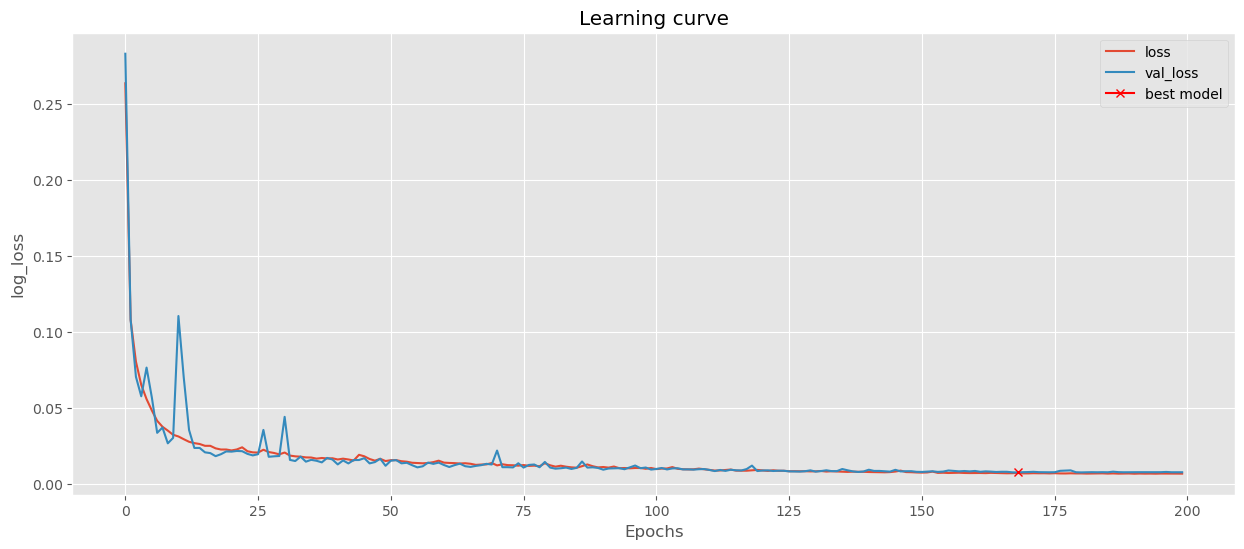

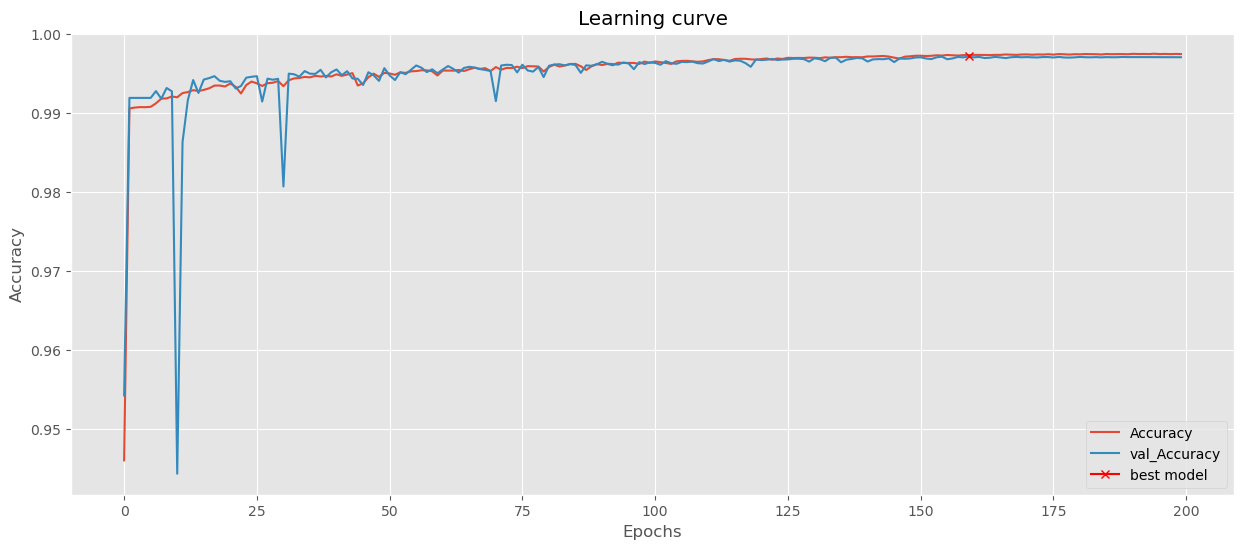

In [13]:
plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["acc"], label="Accuracy")
plt.plot(results.history["val_acc"], label="val_Accuracy")
plt.plot(np.argmax(results.history["val_acc"]), np.max(results.history["val_acc"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();
# plt.figure(figsize = (15,6))
# plt.title("Learning curve")
# plt.plot(results.history["accuracy"], label="Accuracy")
# plt.plot(results.history["val_accuracy"], label="val_Accuracy")
# plt.plot(np.argmax(results.history["val_accuracy"]), np.max(results.history["val_accuracy"]), marker="x", color="r", label="best model")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.legend();

# 模型测试

In [14]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *



# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(
    r'D:\tensorflow\tf\WTB\sd\Nadam-0.0005\UNet-8\5\UNet.h5', custom_objects={

})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
  Accuracy  : 0.9973
  Precision : 0.8324
  Recall    : 0.8189
  F1 Score  : 0.8256
  MCC       : 0.8243
  IoU       : 0.7030


In [15]:
#输出的路径
import os
name='ATTUNet'
Path = '../sd/Nadam-0.0005/ATTUNet-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 


../sd/Nadam-0.0005/ATTUNet-8/4/


In [16]:
from model.AttUNet import *  #加载model_unet.py文件

In [17]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()


input_size =(h,w,3)
model =AttUNet(nClasses=1, input_height=256, input_width=256)
learning_rate = 0.0005  # 根据需要调整学习率的值
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.937)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

484

In [18]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [19]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=300)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [20]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000500
Epoch 1/200
99/99 [==============================] - 25s 215ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.3354 - Recall: 0.0724 - Precision: 0.0157 - TP: 68747.0000 - TN: 97955448.0000 - FN: 881362.0000 - FP: 4313639.0000 - acc: 0.9497 - val_loss: 0.5761 - val_Recall: 0.0513 - val_Precision: 0.0087 - val_TP: 12212.0000 - val_TN: 27862582.0000 - val_FN: 226049.0000 - val_FP: 1390362.0000 - val_acc: 0.9452
Epoch 2: Learning rate set to 0.000500
Epoch 2/200
99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.1784 - Recall: 0.0014 - Precision: 0.0224 - TP: 1334.0000 - TN: 102210752.0000 - FN: 948775.0000 - FP: 58348.0000 - acc: 0.9902 - val_loss: 0.1904 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252942.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 3: Learning rate set to 0.000500
Epoch 3/200
99/99 [==============================] - 

99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0255 - Recall: 0.3682 - Precision: 0.7259 - TP: 349834.0000 - TN: 102136992.0000 - FN: 600275.0000 - FP: 132078.0000 - acc: 0.9929 - val_loss: 0.0236 - val_Recall: 0.5245 - val_Precision: 0.5941 - val_TP: 124958.0000 - val_TN: 29167552.0000 - val_FN: 113303.0000 - val_FP: 85390.0000 - val_acc: 0.9933
Epoch 20: Learning rate set to 0.000489
Epoch 20/200
99/99 [==============================] - 19s 193ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0245 - Recall: 0.3862 - Precision: 0.7348 - TP: 366967.0000 - TN: 102136632.0000 - FN: 583142.0000 - FP: 132433.0000 - acc: 0.9931 - val_loss: 0.0221 - val_Recall: 0.2204 - val_Precision: 0.9066 - val_TP: 52516.0000 - val_TN: 29247526.0000 - val_FN: 185745.0000 - val_FP: 5413.0000 - val_acc: 0.9935
Epoch 21: Learning rate set to 0.000488
Epoch 21/200
99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - los

99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0166 - Recall: 0.5727 - Precision: 0.7910 - TP: 544145.0000 - TN: 102125256.0000 - FN: 405964.0000 - FP: 143811.0000 - acc: 0.9947 - val_loss: 0.0157 - val_Recall: 0.6641 - val_Precision: 0.6640 - val_TP: 158227.0000 - val_TN: 29172882.0000 - val_FN: 80034.0000 - val_FP: 80056.0000 - val_acc: 0.9946
Epoch 38: Learning rate set to 0.000459
Epoch 38/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0165 - Recall: 0.5831 - Precision: 0.7908 - TP: 554040.0000 - TN: 102122576.0000 - FN: 396069.0000 - FP: 146523.0000 - acc: 0.9947 - val_loss: 0.0160 - val_Recall: 0.4897 - val_Precision: 0.7824 - val_TP: 116670.0000 - val_TN: 29220482.0000 - val_FN: 121591.0000 - val_FP: 32457.0000 - val_acc: 0.9948
Epoch 39: Learning rate set to 0.000457
Epoch 39/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - lo

Epoch 55: Learning rate set to 0.000415
Epoch 55/200
99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0167 - Recall: 0.5855 - Precision: 0.7674 - TP: 556276.0000 - TN: 102100480.0000 - FN: 393833.0000 - FP: 168613.0000 - acc: 0.9946 - val_loss: 0.0344 - val_Recall: 0.4532 - val_Precision: 0.4549 - val_TP: 107982.0000 - val_TN: 29123532.0000 - val_FN: 130279.0000 - val_FP: 129412.0000 - val_acc: 0.9912
Epoch 56: Learning rate set to 0.000412
Epoch 56/200
99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0160 - Recall: 0.5939 - Precision: 0.7693 - TP: 564308.0000 - TN: 102099904.0000 - FN: 385801.0000 - FP: 169216.0000 - acc: 0.9946 - val_loss: 0.0184 - val_Recall: 0.7765 - val_Precision: 0.5383 - val_TP: 185020.0000 - val_TN: 29094228.0000 - val_FN: 53241.0000 - val_FP: 158716.0000 - val_acc: 0.9928
Epoch 57: Learning rate set to 0.000409
Epoch 57/200
99/99 [==============================]

99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0110 - Recall: 0.7109 - Precision: 0.8514 - TP: 675451.0000 - TN: 102151216.0000 - FN: 274658.0000 - FP: 117915.0000 - acc: 0.9962 - val_loss: 0.0105 - val_Recall: 0.7007 - val_Precision: 0.7948 - val_TP: 166945.0000 - val_TN: 29209834.0000 - val_FN: 71316.0000 - val_FP: 43105.0000 - val_acc: 0.9961
Epoch 74: Learning rate set to 0.000353
Epoch 74/200
99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0117 - Recall: 0.6886 - Precision: 0.8483 - TP: 654241.0000 - TN: 102152056.0000 - FN: 295868.0000 - FP: 117039.0000 - acc: 0.9960 - val_loss: 0.0104 - val_Recall: 0.6775 - val_Precision: 0.8138 - val_TP: 161431.0000 - val_TN: 29216000.0000 - val_FN: 76830.0000 - val_FP: 36944.0000 - val_acc: 0.9961
Epoch 75: Learning rate set to 0.000349
Epoch 75/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - los

...

99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0068 - Recall: 0.8248 - Precision: 0.8928 - TP: 783643.0000 - TN: 102175032.0000 - FN: 166466.0000 - FP: 94064.0000 - acc: 0.9975 - val_loss: 0.0076 - val_Recall: 0.7962 - val_Precision: 0.8506 - val_TP: 189693.0000 - val_TN: 29219632.0000 - val_FN: 48568.0000 - val_FP: 33308.0000 - val_acc: 0.9972
Epoch 128: Learning rate set to 0.000147
Epoch 128/200
99/99 [==============================] - 19s 192ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0070 - Recall: 0.8218 - Precision: 0.8931 - TP: 780782.0000 - TN: 102175672.0000 - FN: 169327.0000 - FP: 93426.0000 - acc: 0.9975 - val_loss: 0.0079 - val_Recall: 0.7587 - val_Precision: 0.8773 - val_TP: 180764.0000 - val_TN: 29227666.0000 - val_FN: 57497.0000 - val_FP: 25277.0000 - val_acc: 0.9972
Epoch 129: Learning rate set to 0.000144
Epoch 129/200
99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 19s 189ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0062 - Recall: 0.8366 - Precision: 0.8980 - TP: 794834.0000 - TN: 102178832.0000 - FN: 155275.0000 - FP: 90278.0000 - acc: 0.9976 - val_loss: 0.0074 - val_Recall: 0.8246 - val_Precision: 0.8333 - val_TP: 196469.0000 - val_TN: 29213640.0000 - val_FN: 41792.0000 - val_FP: 39298.0000 - val_acc: 0.9973
Epoch 146: Learning rate set to 0.000088
Epoch 146/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0067 - Recall: 0.8301 - Precision: 0.8881 - TP: 788666.0000 - TN: 102169776.0000 - FN: 161443.0000 - FP: 99333.0000 - acc: 0.9975 - val_loss: 0.0076 - val_Recall: 0.8176 - val_Precision: 0.8365 - val_TP: 194795.0000 - val_TN: 29214872.0000 - val_FN: 43466.0000 - val_FP: 38065.0000 - val_acc: 0.9972
Epoch 147: Learning rate set to 0.000085
Epoch 147/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0057 - Recall: 0.8528 - Precision: 0.9022 - TP: 810215.0000 - TN: 102181248.0000 - FN: 139894.0000 - FP: 87842.0000 - acc: 0.9978 - val_loss: 0.0074 - val_Recall: 0.8179 - val_Precision: 0.8460 - val_TP: 194884.0000 - val_TN: 29217472.0000 - val_FN: 43377.0000 - val_FP: 35465.0000 - val_acc: 0.9973
Epoch 164: Learning rate set to 0.000041
Epoch 164/200
99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0056 - Recall: 0.8537 - Precision: 0.9040 - TP: 811066.0000 - TN: 102182944.0000 - FN: 139043.0000 - FP: 86118.0000 - acc: 0.9978 - val_loss: 0.0075 - val_Recall: 0.8121 - val_Precision: 0.8427 - val_TP: 193499.0000 - val_TN: 29216824.0000 - val_FN: 44762.0000 - val_FP: 36115.0000 - val_acc: 0.9973
Epoch 165: Learning rate set to 0.000039
Epoch 165/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0054 - Recall: 0.8585 - Precision: 0.9048 - TP: 815659.0000 - TN: 102183256.0000 - FN: 134450.0000 - FP: 85840.0000 - acc: 0.9979 - val_loss: 0.0072 - val_Recall: 0.8164 - val_Precision: 0.8548 - val_TP: 194514.0000 - val_TN: 29219902.0000 - val_FN: 43747.0000 - val_FP: 33037.0000 - val_acc: 0.9974
Epoch 182: Learning rate set to 0.000011
Epoch 182/200
99/99 [==============================] - 19s 191ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0054 - Recall: 0.8553 - Precision: 0.9080 - TP: 812648.0000 - TN: 102186752.0000 - FN: 137461.0000 - FP: 82343.0000 - acc: 0.9979 - val_loss: 0.0072 - val_Recall: 0.8228 - val_Precision: 0.8518 - val_TP: 196048.0000 - val_TN: 29218842.0000 - val_FN: 42213.0000 - val_FP: 34097.0000 - val_acc: 0.9974
Epoch 183: Learning rate set to 0.000010
Epoch 183/200
99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0053 - Recall: 0.8625 - Precision: 0.9064 - TP: 819484.0000 - TN: 102184512.0000 - FN: 130625.0000 - FP: 84586.0000 - acc: 0.9979 - val_loss: 0.0072 - val_Recall: 0.8252 - val_Precision: 0.8493 - val_TP: 196620.0000 - val_TN: 29218038.0000 - val_FN: 41641.0000 - val_FP: 34900.0000 - val_acc: 0.9974
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 19s 190ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0054 - Recall: 0.8597 - Precision: 0.9073 - TP: 816763.0000 - TN: 102185664.0000 - FN: 133346.0000 - FP: 83423.0000 - acc: 0.9979 - val_loss: 0.0072 - val_Recall: 0.8250 - val_Precision: 0.8496 - val_TP: 196563.0000 - val_TN: 29218142.0000 - val_FN: 41698.0000 - val_FP: 34796.0000 - val_acc: 0.9974


In [21]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [22]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
171,0.005439,0.856992,0.906488,814236.0,102185096.0,135873.0,83995.0,0.997870,0.007122,0.820562,0.853605,195508.0,29219408.0,42753.0,33530.0,0.997413
165,0.005571,0.853688,0.906309,811097.0,102185240.0,139012.0,83848.0,0.997841,0.007126,0.805562,0.863265,191934.0,29222540.0,46327.0,30401.0,0.997398
170,0.005475,0.855659,0.905446,812969.0,102184192.0,137140.0,84897.0,0.997849,0.007141,0.810905,0.862216,193207.0,29222062.0,45054.0,30875.0,0.997425
174,0.005478,0.856418,0.905459,813690.0,102184144.0,136419.0,84959.0,0.997855,0.007151,0.819643,0.851229,195289.0,29218810.0,42972.0,34131.0,0.997386
178,0.005463,0.857385,0.904847,814609.0,102183416.0,135500.0,85664.0,0.997857,0.007171,0.816147,0.854023,194456.0,29219704.0,43805.0,33238.0,0.997388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,0.093537,0.000022,0.003125,21.0,102262392.0,950088.0,6698.0,0.990730,0.078668,0.000000,0.000000,0.0,29252942.0,238261.0,0.0,0.991921
7,0.046186,0.021287,0.806902,20225.0,102264264.0,929884.0,4840.0,0.990945,0.110832,0.599162,0.116095,142757.0,28166044.0,95504.0,1086900.0,0.959907
2,0.123559,0.000294,0.018960,279.0,102254688.0,949830.0,14436.0,0.990658,0.114798,0.000000,0.000000,0.0,29252942.0,238261.0,0.0,0.991921
1,0.178355,0.001404,0.022352,1334.0,102210752.0,948775.0,58348.0,0.990243,0.190350,0.000000,0.000000,0.0,29252942.0,238261.0,0.0,0.991921


In [23]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *



# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(
    r'D:\tensorflow\tf\WTB\sd\Nadam-0.0005\ATTUNet-8\4\ATTUNet.h5', custom_objects={

})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
# print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

  Precision : 0.8507
  Recall    : 0.8182
  F1 Score  : 0.8341
  MCC       : 0.8330
  IoU       : 0.7155


In [15]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [16]:
#输出的路径
import os
name='DeepLab3+'
Path = '../sd/Nadam-0.0005/DeepLab3+-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 


../sd/Nadam-0.0005/DeepLab3+-8/3/


In [17]:
from model.DeepLab3 import *  #加载model_unet.py文件
h, w = 256,256
border = 5 


In [18]:
import glob
import gc
import numpy as np
from tqdm import tqdm
from keras.preprocessing.image import load_img, img_to_array
from skimage.transform import resize
import tensorflow as tf

# ── 训练集加载 ────────────────────────────────────────────────
train      = sorted(glob.glob("../dataset/train/images/*"))
train_mask = sorted(glob.glob("../dataset/train/masks/*"))

X = np.zeros((len(train),      h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X[n]  = x_img / 255.0
    y[n]  = mask  / 255.0

print(X.shape, y.shape)
gc.collect()

# ── 验证集加载 ────────────────────────────────────────────────
valid      = sorted(glob.glob("../dataset/valid/images/*"))
valid_mask = sorted(glob.glob("../dataset/valid/masks/*"))

X_valid = np.zeros((len(valid),      h, w, 3), dtype=np.float32)
y_valid = np.zeros((len(valid_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(valid, valid_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X_valid[n] = x_img / 255.0
    y_valid[n] = mask  / 255.0

print(X_valid.shape, y_valid.shape)
gc.collect()

# ── 数据增强函数 ──────────────────────────────────────────────
def augment_batch(X, y):
    X_aug = X.copy()
    y_aug = y.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:
            X_aug[i] = np.fliplr(X_aug[i])
            y_aug[i] = np.fliplr(y_aug[i])
        if np.random.rand() > 0.5:
            X_aug[i] = np.flipud(X_aug[i])
            y_aug[i] = np.flipud(y_aug[i])
        k = np.random.randint(0, 4)
        if k > 0:
            X_aug[i] = np.rot90(X_aug[i], k)
            y_aug[i] = np.rot90(y_aug[i], k)
        delta = np.random.uniform(-0.1, 0.1)
        X_aug[i] = np.clip(X_aug[i] + delta, 0.0, 1.0)
        factor = np.random.uniform(0.9, 1.1)
        X_aug[i] = np.clip((X_aug[i] - 0.5) * factor + 0.5, 0.0, 1.0)
    return X_aug, y_aug

# ── 生成器（每 epoch 动态增强，不翻倍内存）───────────────────
class AugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=8, augment=True):
        self.X          = X
        self.y          = y
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        if self.augment:
            X_batch, y_batch = augment_batch(X_batch, y_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AugmentGenerator(X,       y,       batch_size=16, augment=True)
valid_gen = AugmentGenerator(X_valid, y_valid, batch_size=16, augment=False)

print(f"训练集: {len(train_gen)} steps/epoch，验证集: {len(valid_gen)} steps/epoch")
gc.collect()

1575it [00:17, 90.04it/s]


(1575, 256, 256, 3) (1575, 256, 256, 1)


450it [00:05, 89.94it/s]


(450, 256, 256, 3) (450, 256, 256, 1)
训练集: 99 steps/epoch，验证集: 29 steps/epoch


0

In [19]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ["SM_FRAMEWORK"] = "tf.keras"
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm
from utils.loss import *
from utils.metrics import *
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D,LSTM,DepthwiseConv2D,BatchNormalization
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K

  
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model

import random 
random_seed = 42
random.seed(random_seed) # set random seed for python
np.random.seed(random_seed) # set random seed for numpy
tf.random.set_seed(random_seed) # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC OPS'] = '1' # set random seed for tensorflow-gpu
## Seeding 
# seed = 2019
# random.seed = seed
# np.random.seed = seed
# tf.seed = seed

In [20]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()


input_size =(h,w,3)
input_img = Input((h, w, 3), name='img')
model = DeeplabV3_plus()
learning_rate = 0.0005  # 根据需要调整学习率的值
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.937)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

488

In [21]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 128, 128, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                           

In [22]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [23]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=300)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [24]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000500
Epoch 1/200
99/99 [==============================] - 86s 699ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.1021 - Recall: 0.0018 - Precision: 0.0025 - TP: 1677.0000 - TN: 101586400.0000 - FN: 948432.0000 - FP: 682679.0000 - acc: 0.9842 - val_loss: 0.2570 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252940.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 2: Learning rate set to 0.000500
Epoch 2/200
99/99 [==============================] - 40s 401ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0447 - Recall: 9.7252e-04 - Precision: 0.1329 - TP: 924.0000 - TN: 102263072.0000 - FN: 949185.0000 - FP: 6026.0000 - acc: 0.9907 - val_loss: 0.0912 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252938.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 3: Learning rate set to 0.000500
Epoch 3/200
99/99 [===========================

99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0222 - Recall: 0.3759 - Precision: 0.7276 - TP: 357127.0000 - TN: 102135424.0000 - FN: 592982.0000 - FP: 133680.0000 - acc: 0.9930 - val_loss: 0.0217 - val_Recall: 0.2413 - val_Precision: 0.8483 - val_TP: 57497.0000 - val_TN: 29242652.0000 - val_FN: 180764.0000 - val_FP: 10282.0000 - val_acc: 0.9935
Epoch 20: Learning rate set to 0.000489
Epoch 20/200
99/99 [==============================] - 40s 402ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0212 - Recall: 0.4114 - Precision: 0.7432 - TP: 390856.0000 - TN: 102134040.0000 - FN: 559253.0000 - FP: 135038.0000 - acc: 0.9933 - val_loss: 0.0201 - val_Recall: 0.4807 - val_Precision: 0.6545 - val_TP: 114529.0000 - val_TN: 29192494.0000 - val_FN: 123732.0000 - val_FP: 60446.0000 - val_acc: 0.9938
Epoch 21: Learning rate set to 0.000488
Epoch 21/200
99/99 [==============================] - 40s 401ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0171 - Recall: 0.5276 - Precision: 0.7849 - TP: 501319.0000 - TN: 102131720.0000 - FN: 448790.0000 - FP: 137364.0000 - acc: 0.9943 - val_loss: 0.0174 - val_Recall: 0.5204 - val_Precision: 0.7065 - val_TP: 123982.0000 - val_TN: 29201432.0000 - val_FN: 114279.0000 - val_FP: 51506.0000 - val_acc: 0.9944
Epoch 38: Learning rate set to 0.000459
Epoch 38/200
99/99 [==============================] - 39s 391ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0168 - Recall: 0.5417 - Precision: 0.7818 - TP: 514686.0000 - TN: 102125464.0000 - FN: 435423.0000 - FP: 143639.0000 - acc: 0.9944 - val_loss: 0.0438 - val_Recall: 0.5620 - val_Precision: 0.2604 - val_TP: 133910.0000 - val_TN: 28872576.0000 - val_FN: 104351.0000 - val_FP: 380365.0000 - val_acc: 0.9836
Epoch 39: Learning rate set to 0.000457
Epoch 39/200
99/99 [==============================] - 39s 395ms/step - batch: 49.0000 - size: 15.9091 - 

99/99 [==============================] - 39s 395ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0136 - Recall: 0.6300 - Precision: 0.8249 - TP: 598563.0000 - TN: 102142056.0000 - FN: 351546.0000 - FP: 127055.0000 - acc: 0.9954 - val_loss: 0.0135 - val_Recall: 0.5709 - val_Precision: 0.8055 - val_TP: 136027.0000 - val_TN: 29220084.0000 - val_FN: 102234.0000 - val_FP: 32854.0000 - val_acc: 0.9954
Epoch 56: Learning rate set to 0.000412
Epoch 56/200
99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0135 - Recall: 0.6396 - Precision: 0.8120 - TP: 607708.0000 - TN: 102128328.0000 - FN: 342401.0000 - FP: 140736.0000 - acc: 0.9953 - val_loss: 0.0139 - val_Recall: 0.6300 - val_Precision: 0.7236 - val_TP: 150098.0000 - val_TN: 29195604.0000 - val_FN: 88163.0000 - val_FP: 57336.0000 - val_acc: 0.9951
Epoch 57: Learning rate set to 0.000409
Epoch 57/200
99/99 [==============================] - 40s 401ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 39s 395ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0115 - Recall: 0.6937 - Precision: 0.8379 - TP: 659107.0000 - TN: 102141568.0000 - FN: 291002.0000 - FP: 127520.0000 - acc: 0.9959 - val_loss: 0.0154 - val_Recall: 0.7488 - val_Precision: 0.6316 - val_TP: 178418.0000 - val_TN: 29148854.0000 - val_FN: 59843.0000 - val_FP: 104084.0000 - val_acc: 0.9944
Epoch 74: Learning rate set to 0.000353
Epoch 74/200
99/99 [==============================] - 40s 402ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0111 - Recall: 0.7079 - Precision: 0.8427 - TP: 672540.0000 - TN: 102143520.0000 - FN: 277569.0000 - FP: 125560.0000 - acc: 0.9961 - val_loss: 0.0116 - val_Recall: 0.6864 - val_Precision: 0.7870 - val_TP: 163535.0000 - val_TN: 29208686.0000 - val_FN: 74726.0000 - val_FP: 44249.0000 - val_acc: 0.9960
Epoch 75: Learning rate set to 0.000349
Epoch 75/200
99/99 [==============================] - 39s 392ms/step - batch: 49.0000 - size: 15.9091 - lo

...

99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0076 - Recall: 0.8010 - Precision: 0.8849 - TP: 761001.0000 - TN: 102170128.0000 - FN: 189108.0000 - FP: 98968.0000 - acc: 0.9972 - val_loss: 0.0094 - val_Recall: 0.7599 - val_Precision: 0.8127 - val_TP: 181052.0000 - val_TN: 29211228.0000 - val_FN: 57209.0000 - val_FP: 41714.0000 - val_acc: 0.9966
Epoch 128: Learning rate set to 0.000147
Epoch 128/200
99/99 [==============================] - 39s 393ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0073 - Recall: 0.8070 - Precision: 0.8865 - TP: 766710.0000 - TN: 102170920.0000 - FN: 183399.0000 - FP: 98159.0000 - acc: 0.9973 - val_loss: 0.0099 - val_Recall: 0.6694 - val_Precision: 0.8760 - val_TP: 159482.0000 - val_TN: 29230360.0000 - val_FN: 78779.0000 - val_FP: 22579.0000 - val_acc: 0.9966
Epoch 129: Learning rate set to 0.000144
Epoch 129/200
99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 39s 390ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0068 - Recall: 0.8187 - Precision: 0.8905 - TP: 777859.0000 - TN: 102173424.0000 - FN: 172250.0000 - FP: 95692.0000 - acc: 0.9974 - val_loss: 0.0102 - val_Recall: 0.7226 - val_Precision: 0.8573 - val_TP: 172159.0000 - val_TN: 29224280.0000 - val_FN: 66102.0000 - val_FP: 28659.0000 - val_acc: 0.9968
Epoch 146: Learning rate set to 0.000088
Epoch 146/200
99/99 [==============================] - 39s 392ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0069 - Recall: 0.8212 - Precision: 0.8906 - TP: 780194.0000 - TN: 102173240.0000 - FN: 169915.0000 - FP: 95850.0000 - acc: 0.9974 - val_loss: 0.0101 - val_Recall: 0.6981 - val_Precision: 0.8797 - val_TP: 166324.0000 - val_TN: 29230192.0000 - val_FN: 71937.0000 - val_FP: 22752.0000 - val_acc: 0.9968
Epoch 147: Learning rate set to 0.000085
Epoch 147/200
99/99 [==============================] - 39s 397ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 39s 393ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0063 - Recall: 0.8336 - Precision: 0.8988 - TP: 792043.0000 - TN: 102179880.0000 - FN: 158066.0000 - FP: 89205.0000 - acc: 0.9976 - val_loss: 0.0093 - val_Recall: 0.7388 - val_Precision: 0.8501 - val_TP: 176021.0000 - val_TN: 29221892.0000 - val_FN: 62240.0000 - val_FP: 31047.0000 - val_acc: 0.9968
Epoch 164: Learning rate set to 0.000041
Epoch 164/200
99/99 [==============================] - 39s 392ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0064 - Recall: 0.8310 - Precision: 0.8966 - TP: 789528.0000 - TN: 102178040.0000 - FN: 160581.0000 - FP: 91035.0000 - acc: 0.9976 - val_loss: 0.0093 - val_Recall: 0.7496 - val_Precision: 0.8381 - val_TP: 178600.0000 - val_TN: 29218428.0000 - val_FN: 59661.0000 - val_FP: 34509.0000 - val_acc: 0.9968
Epoch 165: Learning rate set to 0.000039
Epoch 165/200
99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 39s 393ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0060 - Recall: 0.8383 - Precision: 0.9021 - TP: 796491.0000 - TN: 102182656.0000 - FN: 153618.0000 - FP: 86431.0000 - acc: 0.9977 - val_loss: 0.0092 - val_Recall: 0.7436 - val_Precision: 0.8501 - val_TP: 177174.0000 - val_TN: 29221692.0000 - val_FN: 61087.0000 - val_FP: 31246.0000 - val_acc: 0.9969
Epoch 182: Learning rate set to 0.000011
Epoch 182/200
99/99 [==============================] - 39s 393ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0061 - Recall: 0.8379 - Precision: 0.8997 - TP: 796103.0000 - TN: 102180344.0000 - FN: 154006.0000 - FP: 88751.0000 - acc: 0.9976 - val_loss: 0.0092 - val_Recall: 0.7436 - val_Precision: 0.8524 - val_TP: 177161.0000 - val_TN: 29222266.0000 - val_FN: 61100.0000 - val_FP: 30673.0000 - val_acc: 0.9969
Epoch 183: Learning rate set to 0.000010
Epoch 183/200
99/99 [==============================] - 39s 394ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 39s 392ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0060 - Recall: 0.8407 - Precision: 0.9032 - TP: 798782.0000 - TN: 102183496.0000 - FN: 151327.0000 - FP: 85613.0000 - acc: 0.9977 - val_loss: 0.0094 - val_Recall: 0.7399 - val_Precision: 0.8516 - val_TP: 176288.0000 - val_TN: 29222212.0000 - val_FN: 61973.0000 - val_FP: 30727.0000 - val_acc: 0.9969
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 39s 392ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0060 - Recall: 0.8424 - Precision: 0.9019 - TP: 800378.0000 - TN: 102182096.0000 - FN: 149731.0000 - FP: 87018.0000 - acc: 0.9977 - val_loss: 0.0094 - val_Recall: 0.7399 - val_Precision: 0.8516 - val_TP: 176286.0000 - val_TN: 29222220.0000 - val_FN: 61975.0000 - val_FP: 30721.0000 - val_acc: 0.9969


In [25]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [26]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
156,0.006428,0.829031,0.896198,787670.0,102177880.0,162439.0,91232.0,0.997542,0.009107,0.726506,0.859231,173098.0,29224580.0,65163.0,28359.0,0.996829
155,0.006506,0.828104,0.896043,786789.0,102177816.0,163320.0,91282.0,0.997533,0.009120,0.731458,0.850975,174278.0,29222420.0,63983.0,30520.0,0.996796
159,0.006596,0.824382,0.894491,783253.0,102176704.0,166856.0,92388.0,0.997489,0.009134,0.735454,0.858642,175230.0,29224092.0,63031.0,28848.0,0.996884
160,0.006402,0.831413,0.896473,789933.0,102177880.0,160176.0,91223.0,0.997564,0.009137,0.731190,0.862117,174214.0,29225076.0,64047.0,27863.0,0.996884
124,0.007774,0.794165,0.881998,754543.0,102168112.0,195566.0,100950.0,0.997127,0.009150,0.710544,0.861653,169295.0,29225756.0,68966.0,27182.0,0.996740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,0.034408,0.056747,0.725653,53916.0,102248712.0,896193.0,20384.0,0.991120,0.047946,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
2,0.040244,0.008812,0.256999,8372.0,102244880.0,941737.0,24204.0,0.990642,0.050454,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
4,0.032794,0.098450,0.635384,93538.0,102215432.0,856571.0,53677.0,0.991181,0.053053,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
1,0.044885,0.000973,0.132950,924.0,102263072.0,949185.0,6026.0,0.990746,0.091189,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921


In [27]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *

# 自定义模块和层
from utils.loss import *
from utils.metrics import * 

# 自定义模块和层
from utils.loss import *
from utils.metrics import * 

from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer, InputSpec

def normalize_data_format(value):
    if value is None:
        value = tf.keras.backend.image_data_format()
    data_format = value.lower()
    if data_format not in {'channels_first', 'channels_last'}:
        raise ValueError('The `data_format` argument must be one of "channels_first", "channels_last". Received: ' + str(value))
    return data_format
class BilinearUpsampling(Layer):

    def __init__(self, upsampling=(2, 2), size=None, data_format=None, **kwargs):
        if size is not None:
            upsampling = size
        super(BilinearUpsampling, self).__init__(**kwargs)
        self.data_format = normalize_data_format(data_format)
        self.upsampling = (int(upsampling[0]), int(upsampling[1]))
        self.input_spec = InputSpec(ndim=4)

    def compute_output_shape(self, input_shape):
        height = self.upsampling[0] * \
                 input_shape[1] if input_shape[1] is not None else None
        width = self.upsampling[1] * \
                input_shape[2] if input_shape[2] is not None else None
        return (input_shape[0], height, width, input_shape[3])

    def call(self, inputs):
        return tf.compat.v1.image.resize_bilinear(
            inputs, 
            (int(inputs.shape[1] * self.upsampling[0]), int(inputs.shape[2] * self.upsampling[1]))
        )

    def get_config(self):
        config = {'upsampling': self.upsampling, 'data_format': self.data_format}
        base_config = super(BilinearUpsampling, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))
    
    
def wrap_custom_layer(layer_class):
    def wrapper(*args, **kwargs):

        return layer_class(*args, **kwargs)
    return wrapper
# 自定义层包装器
def wrap_custom_layer(layer_class):
    def wrapper(*args, **kwargs):

        return layer_class(*args, **kwargs)
    return wrapper


# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(
    r'D:\tensorflow\tf\WTB\sd\Nadam-0.0005\DeepLab3+-8\3\DeepLab3+.h5', 
         custom_objects={
'BilinearUpsampling':BilinearUpsampling
})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
# print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

  Precision : 0.8453
  Recall    : 0.7443
  F1 Score  : 0.7916
  MCC       : 0.7917
  IoU       : 0.6551


In [37]:
#输出的路径
import os
name='ICNet'
Path = '../sd/Nadam-0.0005/ICNet-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 

../sd/Nadam-0.0005/ICNet-8/3/


In [38]:
from model.ICNet import *  #加载model_unet.py文件

h, w = 256,256
border = 5 

In [39]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ["SM_FRAMEWORK"] = "tf.keras"
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm
from utils.loss import *
from utils.metrics import *
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D,LSTM,DepthwiseConv2D,BatchNormalization
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K

  
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model

import random 
random_seed = 42
random.seed(random_seed) # set random seed for python
np.random.seed(random_seed) # set random seed for numpy
tf.random.set_seed(random_seed) # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC OPS'] = '1' # set random seed for tensorflow-gpu
## Seeding 
# seed = 2019
# random.seed = seed
# np.random.seed = seed
# tf.seed = seed

In [40]:
import glob
import gc
import numpy as np
from tqdm import tqdm
from keras.preprocessing.image import load_img, img_to_array
from skimage.transform import resize
import tensorflow as tf

# ── 训练集加载 ────────────────────────────────────────────────
train      = sorted(glob.glob("../dataset/train/images/*"))
train_mask = sorted(glob.glob("../dataset/train/masks/*"))

X = np.zeros((len(train),      h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X[n]  = x_img / 255.0
    y[n]  = mask  / 255.0

print(X.shape, y.shape)
gc.collect()

# ── 验证集加载 ────────────────────────────────────────────────
valid      = sorted(glob.glob("../dataset/valid/images/*"))
valid_mask = sorted(glob.glob("../dataset/valid/masks/*"))

X_valid = np.zeros((len(valid),      h, w, 3), dtype=np.float32)
y_valid = np.zeros((len(valid_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(valid, valid_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X_valid[n] = x_img / 255.0
    y_valid[n] = mask  / 255.0

print(X_valid.shape, y_valid.shape)
gc.collect()

# ── 数据增强函数 ──────────────────────────────────────────────
def augment_batch(X, y):
    X_aug = X.copy()
    y_aug = y.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:
            X_aug[i] = np.fliplr(X_aug[i])
            y_aug[i] = np.fliplr(y_aug[i])
        if np.random.rand() > 0.5:
            X_aug[i] = np.flipud(X_aug[i])
            y_aug[i] = np.flipud(y_aug[i])
        k = np.random.randint(0, 4)
        if k > 0:
            X_aug[i] = np.rot90(X_aug[i], k)
            y_aug[i] = np.rot90(y_aug[i], k)
        delta = np.random.uniform(-0.1, 0.1)
        X_aug[i] = np.clip(X_aug[i] + delta, 0.0, 1.0)
        factor = np.random.uniform(0.9, 1.1)
        X_aug[i] = np.clip((X_aug[i] - 0.5) * factor + 0.5, 0.0, 1.0)
    return X_aug, y_aug

# ── 生成器（每 epoch 动态增强，不翻倍内存）───────────────────
class AugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=8, augment=True):
        self.X          = X
        self.y          = y
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        if self.augment:
            X_batch, y_batch = augment_batch(X_batch, y_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AugmentGenerator(X,       y,       batch_size=16, augment=True)
valid_gen = AugmentGenerator(X_valid, y_valid, batch_size=16, augment=False)

print(f"训练集: {len(train_gen)} steps/epoch，验证集: {len(valid_gen)} steps/epoch")
gc.collect()

1575it [00:19, 81.80it/s]


(1575, 256, 256, 3) (1575, 256, 256, 1)


450it [00:05, 81.96it/s]


(450, 256, 256, 3) (450, 256, 256, 1)
训练集: 99 steps/epoch，验证集: 29 steps/epoch


0

In [41]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()


input_size =(h,w,3)
model = ICNet(nClasses=1, input_height=256, input_width=256)
learning_rate = 0.0005  # 根据需要调整学习率的值
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.937)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

1572

In [42]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 data_sub2 (Lambda)             (None, 128, 128, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_1_3x3_s2 (Conv2D)        (None, 64, 64, 32)   896         ['data_sub2[0][0]']              
                                                                                                  
 conv1_1_3x3_s2_bn (BatchNormal  (None, 64, 64, 32)  128         ['conv1_1_3x3_s2[0][0]']   

In [43]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [44]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=100)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [45]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000500
Epoch 1/200
99/99 [==============================] - 32s 247ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.1827 - Recall: 0.0336 - Precision: 0.0060 - TP: 31942.0000 - TN: 96934384.0000 - FN: 918167.0000 - FP: 5334673.0000 - acc: 0.9394 - val_loss: 0.1351 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252788.0000 - val_FN: 238261.0000 - val_FP: 150.0000 - val_acc: 0.9919
Epoch 2: Learning rate set to 0.000500
Epoch 2/200
99/99 [==============================] - 17s 177ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0496 - Recall: 0.0050 - Precision: 0.0953 - TP: 4728.0000 - TN: 102224144.0000 - FN: 945381.0000 - FP: 44907.0000 - acc: 0.9904 - val_loss: 0.0801 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29249956.0000 - val_FN: 238261.0000 - val_FP: 2981.0000 - val_acc: 0.9918
Epoch 3: Learning rate set to 0.000500
Epoch 3/200
99/99 [==============================]

99/99 [==============================] - 17s 174ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0276 - Recall: 0.2550 - Precision: 0.7598 - TP: 242259.0000 - TN: 102192504.0000 - FN: 707850.0000 - FP: 76590.0000 - acc: 0.9924 - val_loss: 0.0747 - val_Recall: 0.5472 - val_Precision: 0.1800 - val_TP: 130370.0000 - val_TN: 28659016.0000 - val_FN: 107891.0000 - val_FP: 593924.0000 - val_acc: 0.9762
Epoch 20: Learning rate set to 0.000489
Epoch 20/200
99/99 [==============================] - 17s 173ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0268 - Recall: 0.2763 - Precision: 0.7452 - TP: 262506.0000 - TN: 102179304.0000 - FN: 687603.0000 - FP: 89780.0000 - acc: 0.9925 - val_loss: 0.0259 - val_Recall: 0.2400 - val_Precision: 0.6354 - val_TP: 57180.0000 - val_TN: 29220128.0000 - val_FN: 181081.0000 - val_FP: 32812.0000 - val_acc: 0.9927
Epoch 21: Learning rate set to 0.000488
Epoch 21/200
99/99 [==============================] - 17s 173ms/step - batch: 49.0000 - size: 15.9091 - los

99/99 [==============================] - 17s 172ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0235 - Recall: 0.3727 - Precision: 0.7690 - TP: 354142.0000 - TN: 102162720.0000 - FN: 595967.0000 - FP: 106371.0000 - acc: 0.9932 - val_loss: 0.0215 - val_Recall: 0.3948 - val_Precision: 0.7080 - val_TP: 94059.0000 - val_TN: 29214146.0000 - val_FN: 144202.0000 - val_FP: 38795.0000 - val_acc: 0.9938
Epoch 38: Learning rate set to 0.000459
Epoch 38/200
99/99 [==============================] - 18s 178ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0229 - Recall: 0.3756 - Precision: 0.7781 - TP: 356885.0000 - TN: 102167328.0000 - FN: 593224.0000 - FP: 101780.0000 - acc: 0.9933 - val_loss: 0.0203 - val_Recall: 0.4297 - val_Precision: 0.6963 - val_TP: 102388.0000 - val_TN: 29208292.0000 - val_FN: 135873.0000 - val_FP: 44649.0000 - val_acc: 0.9939
Epoch 39: Learning rate set to 0.000457
Epoch 39/200
99/99 [==============================] - 17s 174ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 17s 170ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0203 - Recall: 0.4322 - Precision: 0.7891 - TP: 410608.0000 - TN: 102159368.0000 - FN: 539501.0000 - FP: 109729.0000 - acc: 0.9937 - val_loss: 0.0233 - val_Recall: 0.5809 - val_Precision: 0.5425 - val_TP: 138394.0000 - val_TN: 29136228.0000 - val_FN: 99867.0000 - val_FP: 116707.0000 - val_acc: 0.9927
Epoch 56: Learning rate set to 0.000412
Epoch 56/200
99/99 [==============================] - 17s 174ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0197 - Recall: 0.4736 - Precision: 0.7974 - TP: 449938.0000 - TN: 102154752.0000 - FN: 500171.0000 - FP: 114328.0000 - acc: 0.9940 - val_loss: 0.0179 - val_Recall: 0.4378 - val_Precision: 0.7708 - val_TP: 104318.0000 - val_TN: 29221924.0000 - val_FN: 133943.0000 - val_FP: 31017.0000 - val_acc: 0.9944
Epoch 57: Learning rate set to 0.000409
Epoch 57/200
99/99 [==============================] - 17s 170ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 17s 171ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0168 - Recall: 0.5479 - Precision: 0.8130 - TP: 520578.0000 - TN: 102149344.0000 - FN: 429531.0000 - FP: 119743.0000 - acc: 0.9947 - val_loss: 0.0287 - val_Recall: 0.6370 - val_Precision: 0.4292 - val_TP: 151765.0000 - val_TN: 29051080.0000 - val_FN: 86496.0000 - val_FP: 201863.0000 - val_acc: 0.9902
Epoch 74: Learning rate set to 0.000353
Epoch 74/200
99/99 [==============================] - 17s 171ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0171 - Recall: 0.5362 - Precision: 0.8127 - TP: 509468.0000 - TN: 102151656.0000 - FN: 440641.0000 - FP: 117438.0000 - acc: 0.9946 - val_loss: 0.0197 - val_Recall: 0.6215 - val_Precision: 0.5807 - val_TP: 148075.0000 - val_TN: 29146028.0000 - val_FN: 90186.0000 - val_FP: 106911.0000 - val_acc: 0.9933
Epoch 75: Learning rate set to 0.000349
Epoch 75/200
99/99 [==============================] - 17s 173ms/step - batch: 49.0000 - size: 15.9091 - l

...

99/99 [==============================] - 18s 184ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0120 - Recall: 0.6837 - Precision: 0.8502 - TP: 649595.0000 - TN: 102154648.0000 - FN: 300514.0000 - FP: 114444.0000 - acc: 0.9960 - val_loss: 0.0136 - val_Recall: 0.6013 - val_Precision: 0.8019 - val_TP: 143265.0000 - val_TN: 29217552.0000 - val_FN: 94996.0000 - val_FP: 35386.0000 - val_acc: 0.9956
Epoch 128: Learning rate set to 0.000147
Epoch 128/200
99/99 [==============================] - 18s 186ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0119 - Recall: 0.6811 - Precision: 0.8534 - TP: 647099.0000 - TN: 102157920.0000 - FN: 303010.0000 - FP: 111158.0000 - acc: 0.9960 - val_loss: 0.0145 - val_Recall: 0.5134 - val_Precision: 0.8615 - val_TP: 122319.0000 - val_TN: 29233272.0000 - val_FN: 115942.0000 - val_FP: 19669.0000 - val_acc: 0.9954
Epoch 129: Learning rate set to 0.000144
Epoch 129/200
99/99 [==============================] - 18s 186ms/step - batch: 49.0000 - size: 15.9091 

99/99 [==============================] - 18s 184ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0108 - Recall: 0.7161 - Precision: 0.8634 - TP: 680340.0000 - TN: 102161456.0000 - FN: 269769.0000 - FP: 107612.0000 - acc: 0.9963 - val_loss: 0.0130 - val_Recall: 0.5976 - val_Precision: 0.8185 - val_TP: 142390.0000 - val_TN: 29221364.0000 - val_FN: 95871.0000 - val_FP: 31576.0000 - val_acc: 0.9957
Epoch 146: Learning rate set to 0.000088
Epoch 146/200
99/99 [==============================] - 18s 185ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0108 - Recall: 0.7160 - Precision: 0.8619 - TP: 680270.0000 - TN: 102160048.0000 - FN: 269839.0000 - FP: 109041.0000 - acc: 0.9963 - val_loss: 0.0131 - val_Recall: 0.6191 - val_Precision: 0.7969 - val_TP: 147498.0000 - val_TN: 29215352.0000 - val_FN: 90763.0000 - val_FP: 37585.0000 - val_acc: 0.9956
Epoch 147: Learning rate set to 0.000085
Epoch 147/200
99/99 [==============================] - 18s 183ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 19s 188ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0103 - Recall: 0.7302 - Precision: 0.8647 - TP: 693724.0000 - TN: 102160480.0000 - FN: 256385.0000 - FP: 108593.0000 - acc: 0.9965 - val_loss: 0.0126 - val_Recall: 0.6438 - val_Precision: 0.7885 - val_TP: 153400.0000 - val_TN: 29211784.0000 - val_FN: 84861.0000 - val_FP: 41158.0000 - val_acc: 0.9957
Epoch 164: Learning rate set to 0.000041
Epoch 164/200
99/99 [==============================] - 18s 185ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0102 - Recall: 0.7283 - Precision: 0.8649 - TP: 691925.0000 - TN: 102160992.0000 - FN: 258184.0000 - FP: 108092.0000 - acc: 0.9965 - val_loss: 0.0126 - val_Recall: 0.6601 - val_Precision: 0.7801 - val_TP: 157280.0000 - val_TN: 29208606.0000 - val_FN: 80981.0000 - val_FP: 44333.0000 - val_acc: 0.9958
Epoch 165: Learning rate set to 0.000039
Epoch 165/200
99/99 [==============================] - 18s 185ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 19s 187ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0098 - Recall: 0.7433 - Precision: 0.8709 - TP: 706195.0000 - TN: 102164416.0000 - FN: 243914.0000 - FP: 104671.0000 - acc: 0.9966 - val_loss: 0.0124 - val_Recall: 0.6465 - val_Precision: 0.7973 - val_TP: 154045.0000 - val_TN: 29213792.0000 - val_FN: 84216.0000 - val_FP: 39153.0000 - val_acc: 0.9958
Epoch 182: Learning rate set to 0.000011
Epoch 182/200
99/99 [==============================] - 18s 185ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0098 - Recall: 0.7440 - Precision: 0.8693 - TP: 706847.0000 - TN: 102162816.0000 - FN: 243262.0000 - FP: 106287.0000 - acc: 0.9966 - val_loss: 0.0124 - val_Recall: 0.6338 - val_Precision: 0.8073 - val_TP: 151001.0000 - val_TN: 29216900.0000 - val_FN: 87260.0000 - val_FP: 36038.0000 - val_acc: 0.9958
Epoch 183: Learning rate set to 0.000010
Epoch 183/200
99/99 [==============================] - 18s 185ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 18s 184ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0098 - Recall: 0.7452 - Precision: 0.8716 - TP: 708009.0000 - TN: 102164824.0000 - FN: 242100.0000 - FP: 104254.0000 - acc: 0.9966 - val_loss: 0.0138 - val_Recall: 0.6391 - val_Precision: 0.8052 - val_TP: 152270.0000 - val_TN: 29216112.0000 - val_FN: 85991.0000 - val_FP: 36830.0000 - val_acc: 0.9958
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 18s 184ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0097 - Recall: 0.7480 - Precision: 0.8717 - TP: 710681.0000 - TN: 102164448.0000 - FN: 239428.0000 - FP: 104644.0000 - acc: 0.9967 - val_loss: 0.0125 - val_Recall: 0.6412 - val_Precision: 0.8031 - val_TP: 152768.0000 - val_TN: 29215488.0000 - val_FN: 85493.0000 - val_FP: 37455.0000 - val_acc: 0.9958


In [46]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [47]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
179,0.009778,0.747921,0.864969,710606.0,102158152.0,239503.0,110933.0,0.996605,0.012364,0.637549,0.803639,151903.0,29215828.0,86358.0,37116.0,0.995813
180,0.009781,0.743278,0.870915,706195.0,102164416.0,243914.0,104671.0,0.996623,0.012408,0.646539,0.797343,154045.0,29213792.0,84216.0,39153.0,0.995817
178,0.009821,0.740238,0.869612,703307.0,102163656.0,246802.0,105453.0,0.996587,0.012425,0.650224,0.790992,154923.0,29212004.0,83338.0,40936.0,0.995786
181,0.009806,0.743964,0.869287,706847.0,102162816.0,243262.0,106287.0,0.996614,0.012429,0.633763,0.807324,151001.0,29216900.0,87260.0,36038.0,0.995819
188,0.009630,0.745200,0.871754,708021.0,102164920.0,242088.0,104159.0,0.996646,0.012441,0.642434,0.803008,153067.0,29215388.0,85194.0,37550.0,0.995838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0.043073,0.024907,0.506485,23664.0,102246024.0,926445.0,23058.0,0.990801,0.066123,0.000579,0.003479,138.0,29213404.0,238123.0,39533.0,0.990585
8,0.032475,0.163883,0.708958,155707.0,102205176.0,794402.0,63921.0,0.991684,0.071950,0.355169,0.217663,84623.0,28948784.0,153638.0,304157.0,0.984477
18,0.027673,0.254980,0.759792,242259.0,102192504.0,707850.0,76590.0,0.992400,0.074715,0.547173,0.179996,130370.0,28659016.0,107891.0,593924.0,0.976203
1,0.049815,0.004976,0.095255,4728.0,102224144.0,945381.0,44907.0,0.990406,0.080066,0.000000,0.000000,0.0,29249956.0,238261.0,2981.0,0.991820


In [48]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *



# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(
    r'D:\tensorflow\tf\WTB\sd\Nadam-0.0005\ICNet-8\3\ICNet.h5', 
         custom_objects={

})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
# print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

  Precision : 0.8070
  Recall    : 0.6467
  F1 Score  : 0.7180
  MCC       : 0.7205
  IoU       : 0.5601


In [49]:
#输出的路径
import os
name='FF-UNet'
Path = '../sd/Nadam-0.0005/FF-UNet-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 

../sd/Nadam-0.0005/FF-UNet-8/3/


In [50]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ["SM_FRAMEWORK"] = "tf.keras"
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm
from utils.loss import *
from utils.metrics import *
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D,LSTM,DepthwiseConv2D,BatchNormalization
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K

  
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model

import random 
random_seed = 42
random.seed(random_seed) # set random seed for python
np.random.seed(random_seed) # set random seed for numpy
tf.random.set_seed(random_seed) # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC OPS'] = '1' # set random seed for tensorflow-gpu
## Seeding 
# seed = 2019
# random.seed = seed
# np.random.seed = seed
# tf.seed = seed
h, w = 256,256
border = 5 

In [51]:
import glob
import gc
import numpy as np
from tqdm import tqdm
from keras.preprocessing.image import load_img, img_to_array
from skimage.transform import resize
import tensorflow as tf

# ── 训练集加载 ────────────────────────────────────────────────
train      = sorted(glob.glob("../dataset/train/images/*"))
train_mask = sorted(glob.glob("../dataset/train/masks/*"))

X = np.zeros((len(train),      h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X[n]  = x_img / 255.0
    y[n]  = mask  / 255.0

print(X.shape, y.shape)
gc.collect()

# ── 验证集加载 ────────────────────────────────────────────────
valid      = sorted(glob.glob("../dataset/valid/images/*"))
valid_mask = sorted(glob.glob("../dataset/valid/masks/*"))

X_valid = np.zeros((len(valid),      h, w, 3), dtype=np.float32)
y_valid = np.zeros((len(valid_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(valid, valid_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X_valid[n] = x_img / 255.0
    y_valid[n] = mask  / 255.0

print(X_valid.shape, y_valid.shape)
gc.collect()

# ── 数据增强函数 ──────────────────────────────────────────────
def augment_batch(X, y):
    X_aug = X.copy()
    y_aug = y.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:
            X_aug[i] = np.fliplr(X_aug[i])
            y_aug[i] = np.fliplr(y_aug[i])
        if np.random.rand() > 0.5:
            X_aug[i] = np.flipud(X_aug[i])
            y_aug[i] = np.flipud(y_aug[i])
        k = np.random.randint(0, 4)
        if k > 0:
            X_aug[i] = np.rot90(X_aug[i], k)
            y_aug[i] = np.rot90(y_aug[i], k)
        delta = np.random.uniform(-0.1, 0.1)
        X_aug[i] = np.clip(X_aug[i] + delta, 0.0, 1.0)
        factor = np.random.uniform(0.9, 1.1)
        X_aug[i] = np.clip((X_aug[i] - 0.5) * factor + 0.5, 0.0, 1.0)
    return X_aug, y_aug

# ── 生成器（每 epoch 动态增强，不翻倍内存）───────────────────
class AugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=8, augment=True):
        self.X          = X
        self.y          = y
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        if self.augment:
            X_batch, y_batch = augment_batch(X_batch, y_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AugmentGenerator(X,       y,       batch_size=16, augment=True)
valid_gen = AugmentGenerator(X_valid, y_valid, batch_size=16, augment=False)

print(f"训练集: {len(train_gen)} steps/epoch，验证集: {len(valid_gen)} steps/epoch")
gc.collect()

1575it [00:18, 83.14it/s]


(1575, 256, 256, 3) (1575, 256, 256, 1)


450it [00:05, 83.30it/s]


(450, 256, 256, 3) (450, 256, 256, 1)
训练集: 99 steps/epoch，验证集: 29 steps/epoch


0

In [52]:
from model.FF_UNet import *

In [53]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()


input_img = Input((h, w, 3), name='img')
model = FF_Unet(input_img)
learning_rate = 0.0005  # 根据需要调整学习率的值
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.937)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

449003

In [54]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 img (InputLayer)               [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  448         ['img[0][0]']                    
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 256, 256, 16  448         ['img[0][0]']                    
                                )                                                             

In [55]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [56]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=300)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [57]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000500
Epoch 1/200
99/99 [==============================] - 40s 319ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.2244 - Recall: 0.0048 - Precision: 0.0095 - TP: 4563.0000 - TN: 101793456.0000 - FN: 945546.0000 - FP: 475640.0000 - acc: 0.9862 - val_loss: 0.4206 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252940.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 2: Learning rate set to 0.000500
Epoch 2/200
99/99 [==============================] - 24s 240ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.1013 - Recall: 0.0000e+00 - Precision: 0.0000e+00 - TP: 0.0000e+00 - TN: 102269040.0000 - FN: 950109.0000 - FP: 58.0000 - acc: 0.9908 - val_loss: 0.2474 - val_Recall: 7.5547e-04 - val_Precision: 0.0017 - val_TP: 180.0000 - val_TN: 29147416.0000 - val_FN: 238081.0000 - val_FP: 105521.0000 - val_acc: 0.9883
Epoch 3: Learning rate set to 0.000500
Epoch 3/200
99/99 [============================

99/99 [==============================] - 23s 237ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0350 - Recall: 0.0907 - Precision: 0.7336 - TP: 86200.0000 - TN: 102237784.0000 - FN: 863909.0000 - FP: 31307.0000 - acc: 0.9913 - val_loss: 0.0367 - val_Recall: 0.1060 - val_Precision: 0.6463 - val_TP: 25247.0000 - val_TN: 29239120.0000 - val_FN: 213014.0000 - val_FP: 13815.0000 - val_acc: 0.9923
Epoch 20: Learning rate set to 0.000489
Epoch 20/200
99/99 [==============================] - 23s 237ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0360 - Recall: 0.0796 - Precision: 0.6675 - TP: 75589.0000 - TN: 102231448.0000 - FN: 874520.0000 - FP: 37659.0000 - acc: 0.9912 - val_loss: 0.0378 - val_Recall: 0.1076 - val_Precision: 0.5732 - val_TP: 25647.0000 - val_TN: 29233844.0000 - val_FN: 212614.0000 - val_FP: 19095.0000 - val_acc: 0.9921
Epoch 21: Learning rate set to 0.000488
Epoch 21/200
99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 - loss: 0

99/99 [==============================] - 24s 241ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0261 - Recall: 0.2940 - Precision: 0.7559 - TP: 279285.0000 - TN: 102178920.0000 - FN: 670824.0000 - FP: 90169.0000 - acc: 0.9926 - val_loss: 0.0222 - val_Recall: 0.2106 - val_Precision: 0.8540 - val_TP: 50175.0000 - val_TN: 29244360.0000 - val_FN: 188086.0000 - val_FP: 8577.0000 - val_acc: 0.9933
Epoch 38: Learning rate set to 0.000459
Epoch 38/200
99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0267 - Recall: 0.2755 - Precision: 0.7239 - TP: 261774.0000 - TN: 102169256.0000 - FN: 688335.0000 - FP: 99855.0000 - acc: 0.9924 - val_loss: 0.0275 - val_Recall: 0.3396 - val_Precision: 0.6541 - val_TP: 80905.0000 - val_TN: 29210160.0000 - val_FN: 157356.0000 - val_FP: 42779.0000 - val_acc: 0.9932
Epoch 39: Learning rate set to 0.000457
Epoch 39/200
99/99 [==============================] - 24s 239ms/step - batch: 49.0000 - size: 15.9091 - loss: 

99/99 [==============================] - 24s 239ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0216 - Recall: 0.4027 - Precision: 0.7693 - TP: 382603.0000 - TN: 102154336.0000 - FN: 567506.0000 - FP: 114765.0000 - acc: 0.9934 - val_loss: 0.0195 - val_Recall: 0.4193 - val_Precision: 0.6950 - val_TP: 99898.0000 - val_TN: 29209094.0000 - val_FN: 138363.0000 - val_FP: 43847.0000 - val_acc: 0.9938
Epoch 56: Learning rate set to 0.000412
Epoch 56/200
99/99 [==============================] - 24s 243ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0208 - Recall: 0.4403 - Precision: 0.7771 - TP: 418346.0000 - TN: 102149128.0000 - FN: 531763.0000 - FP: 119979.0000 - acc: 0.9937 - val_loss: 0.0187 - val_Recall: 0.3140 - val_Precision: 0.8776 - val_TP: 74804.0000 - val_TN: 29242504.0000 - val_FN: 163457.0000 - val_FP: 10434.0000 - val_acc: 0.9941
Epoch 57: Learning rate set to 0.000409
Epoch 57/200
99/99 [==============================] - 23s 237ms/step - batch: 49.0000 - size: 15.9091 - los

99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0177 - Recall: 0.5143 - Precision: 0.7892 - TP: 488631.0000 - TN: 102138600.0000 - FN: 461478.0000 - FP: 130484.0000 - acc: 0.9943 - val_loss: 0.0354 - val_Recall: 0.4966 - val_Precision: 0.3087 - val_TP: 118317.0000 - val_TN: 28988016.0000 - val_FN: 119944.0000 - val_FP: 264922.0000 - val_acc: 0.9869
Epoch 74: Learning rate set to 0.000353
Epoch 74/200
99/99 [==============================] - 24s 242ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0195 - Recall: 0.4745 - Precision: 0.7491 - TP: 450813.0000 - TN: 102118096.0000 - FN: 499296.0000 - FP: 150999.0000 - acc: 0.9937 - val_loss: 0.0160 - val_Recall: 0.4979 - val_Precision: 0.7987 - val_TP: 118640.0000 - val_TN: 29223034.0000 - val_FN: 119621.0000 - val_FP: 29907.0000 - val_acc: 0.9949
Epoch 75: Learning rate set to 0.000349
Epoch 75/200
99/99 [==============================] - 24s 239ms/step - batch: 49.0000 - size: 15.9091 - 

...

99/99 [==============================] - 24s 239ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0129 - Recall: 0.6599 - Precision: 0.8330 - TP: 627017.0000 - TN: 102143408.0000 - FN: 323092.0000 - FP: 125714.0000 - acc: 0.9957 - val_loss: 0.0137 - val_Recall: 0.5919 - val_Precision: 0.7638 - val_TP: 141032.0000 - val_TN: 29209332.0000 - val_FN: 97229.0000 - val_FP: 43607.0000 - val_acc: 0.9952
Epoch 128: Learning rate set to 0.000147
Epoch 128/200
99/99 [==============================] - 24s 239ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0134 - Recall: 0.6402 - Precision: 0.8232 - TP: 608232.0000 - TN: 102138488.0000 - FN: 341877.0000 - FP: 130596.0000 - acc: 0.9954 - val_loss: 0.0132 - val_Recall: 0.6570 - val_Precision: 0.7125 - val_TP: 156536.0000 - val_TN: 29189764.0000 - val_FN: 81725.0000 - val_FP: 63179.0000 - val_acc: 0.9951
Epoch 129: Learning rate set to 0.000144
Epoch 129/200
99/99 [==============================] - 24s 241ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 24s 239ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0119 - Recall: 0.6887 - Precision: 0.8368 - TP: 654368.0000 - TN: 102141520.0000 - FN: 295741.0000 - FP: 127578.0000 - acc: 0.9959 - val_loss: 0.0134 - val_Recall: 0.5586 - val_Precision: 0.8048 - val_TP: 133100.0000 - val_TN: 29220664.0000 - val_FN: 105161.0000 - val_FP: 32276.0000 - val_acc: 0.9953
Epoch 146: Learning rate set to 0.000088
Epoch 146/200
99/99 [==============================] - 24s 240ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0120 - Recall: 0.6870 - Precision: 0.8454 - TP: 652731.0000 - TN: 102149752.0000 - FN: 297378.0000 - FP: 119322.0000 - acc: 0.9960 - val_loss: 0.0122 - val_Recall: 0.6944 - val_Precision: 0.7452 - val_TP: 165437.0000 - val_TN: 29196368.0000 - val_FN: 72824.0000 - val_FP: 56570.0000 - val_acc: 0.9956
Epoch 147: Learning rate set to 0.000085
Epoch 147/200
99/99 [==============================] - 24s 243ms/step - batch: 49.0000 - size: 15.9091 

99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0115 - Recall: 0.6984 - Precision: 0.8434 - TP: 663578.0000 - TN: 102145848.0000 - FN: 286531.0000 - FP: 123249.0000 - acc: 0.9960 - val_loss: 0.0115 - val_Recall: 0.6668 - val_Precision: 0.7890 - val_TP: 158870.0000 - val_TN: 29210454.0000 - val_FN: 79391.0000 - val_FP: 42485.0000 - val_acc: 0.9959
Epoch 164: Learning rate set to 0.000041
Epoch 164/200
99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0114 - Recall: 0.7008 - Precision: 0.8476 - TP: 665810.0000 - TN: 102149352.0000 - FN: 284299.0000 - FP: 119746.0000 - acc: 0.9961 - val_loss: 0.0114 - val_Recall: 0.6848 - val_Precision: 0.7825 - val_TP: 163163.0000 - val_TN: 29207596.0000 - val_FN: 75098.0000 - val_FP: 45346.0000 - val_acc: 0.9959
Epoch 165: Learning rate set to 0.000039
Epoch 165/200
99/99 [==============================] - 24s 240ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 23s 237ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0111 - Recall: 0.7047 - Precision: 0.8517 - TP: 669529.0000 - TN: 102152512.0000 - FN: 280580.0000 - FP: 116577.0000 - acc: 0.9962 - val_loss: 0.0113 - val_Recall: 0.6678 - val_Precision: 0.7973 - val_TP: 159110.0000 - val_TN: 29212490.0000 - val_FN: 79151.0000 - val_FP: 40448.0000 - val_acc: 0.9959
Epoch 182: Learning rate set to 0.000011
Epoch 182/200
99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0110 - Recall: 0.7090 - Precision: 0.8544 - TP: 673606.0000 - TN: 102154344.0000 - FN: 276503.0000 - FP: 114745.0000 - acc: 0.9962 - val_loss: 0.0113 - val_Recall: 0.6822 - val_Precision: 0.7837 - val_TP: 162533.0000 - val_TN: 29208074.0000 - val_FN: 75728.0000 - val_FP: 44862.0000 - val_acc: 0.9959
Epoch 183: Learning rate set to 0.000010
Epoch 183/200
99/99 [==============================] - 24s 238ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 24s 243ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0104 - Recall: 0.7166 - Precision: 0.8657 - TP: 680811.0000 - TN: 102163488.0000 - FN: 269298.0000 - FP: 105590.0000 - acc: 0.9964 - val_loss: 0.0112 - val_Recall: 0.6715 - val_Precision: 0.7955 - val_TP: 159997.0000 - val_TN: 29211804.0000 - val_FN: 78264.0000 - val_FP: 41136.0000 - val_acc: 0.9960
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 24s 243ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0108 - Recall: 0.7137 - Precision: 0.8475 - TP: 678126.0000 - TN: 102147040.0000 - FN: 271983.0000 - FP: 122060.0000 - acc: 0.9962 - val_loss: 0.0112 - val_Recall: 0.6718 - val_Precision: 0.7960 - val_TP: 160057.0000 - val_TN: 29211922.0000 - val_FN: 78204.0000 - val_FP: 41017.0000 - val_acc: 0.9960


In [58]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [59]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
170,0.010935,0.706013,0.858027,670789.0,102158088.0,279320.0,110992.0,0.996219,0.011111,0.677975,0.796115,161535.0,29211564.0,76726.0,41369.0,0.995996
188,0.010729,0.708608,0.860654,673255.0,102160064.0,276854.0,109005.0,0.996262,0.011133,0.675935,0.794864,161049.0,29211374.0,77212.0,41563.0,0.995972
171,0.010914,0.710854,0.848130,675389.0,102148160.0,274720.0,120938.0,0.996167,0.011153,0.659592,0.810788,157155.0,29216264.0,81106.0,36675.0,0.996006
189,0.010942,0.713544,0.847999,677945.0,102147568.0,272164.0,121519.0,0.996186,0.011154,0.671075,0.797748,159891.0,29212402.0,78370.0,40537.0,0.995968
169,0.011199,0.704381,0.843946,669239.0,102145336.0,280870.0,123749.0,0.996080,0.011155,0.659835,0.808692,157213.0,29215746.0,81048.0,37191.0,0.995991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,0.034526,0.102618,0.705418,97498.0,102228384.0,852611.0,40715.0,0.991345,0.060041,0.090107,0.176774,21469.0,29152960.0,216792.0,99980.0,0.989259
3,0.062150,0.000000,0.000000,0.0,102269120.0,950109.0,0.0,0.990795,0.061364,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921
2,0.075335,0.000005,0.000627,5.0,102261112.0,950104.0,7968.0,0.990718,0.085970,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921
1,0.101534,0.000000,0.000000,0.0,102269040.0,950109.0,58.0,0.990795,0.247357,0.000755,0.001703,180.0,29147416.0,238081.0,105521.0,0.988349


In [60]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *



# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(
    r'D:\tensorflow\tf\WTB\sd\Nadam-0.0005\FF-UNet-8\3\FF-UNet.h5', 
         custom_objects={

})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
# print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

  Precision : 0.8335
  Recall    : 0.6559
  F1 Score  : 0.7341
  MCC       : 0.7376
  IoU       : 0.5799


In [12]:
#输出的路径
import os
name='vit'
Path = '../sd/Nadam-0.0005/vit-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 

../sd/Nadam-0.0005/vit-8/3/


In [13]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ["SM_FRAMEWORK"] = "tf.keras"
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm
from utils.loss import *
from utils.metrics import *
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D,LSTM,DepthwiseConv2D,BatchNormalization
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K

  
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model

import random 
random_seed = 42
random.seed(random_seed) # set random seed for python
np.random.seed(random_seed) # set random seed for numpy
tf.random.set_seed(random_seed) # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC OPS'] = '1' # set random seed for tensorflow-gpu
## Seeding 
# seed = 2019
# random.seed = seed
# np.random.seed = seed
# tf.seed = seed
h, w = 256,256
border = 5 

In [14]:
import glob
import gc
import numpy as np
from tqdm import tqdm
from keras.preprocessing.image import load_img, img_to_array
from skimage.transform import resize
import tensorflow as tf

# ── 训练集加载 ────────────────────────────────────────────────
train      = sorted(glob.glob("../dataset/train/images/*"))
train_mask = sorted(glob.glob("../dataset/train/masks/*"))

X = np.zeros((len(train),      h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X[n]  = x_img / 255.0
    y[n]  = mask  / 255.0

print(X.shape, y.shape)
gc.collect()

# ── 验证集加载 ────────────────────────────────────────────────
valid      = sorted(glob.glob("../dataset/valid/images/*"))
valid_mask = sorted(glob.glob("../dataset/valid/masks/*"))

X_valid = np.zeros((len(valid),      h, w, 3), dtype=np.float32)
y_valid = np.zeros((len(valid_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(valid, valid_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X_valid[n] = x_img / 255.0
    y_valid[n] = mask  / 255.0

print(X_valid.shape, y_valid.shape)
gc.collect()

# ── 数据增强函数 ──────────────────────────────────────────────
def augment_batch(X, y):
    X_aug = X.copy()
    y_aug = y.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:
            X_aug[i] = np.fliplr(X_aug[i])
            y_aug[i] = np.fliplr(y_aug[i])
        if np.random.rand() > 0.5:
            X_aug[i] = np.flipud(X_aug[i])
            y_aug[i] = np.flipud(y_aug[i])
        k = np.random.randint(0, 4)
        if k > 0:
            X_aug[i] = np.rot90(X_aug[i], k)
            y_aug[i] = np.rot90(y_aug[i], k)
        delta = np.random.uniform(-0.1, 0.1)
        X_aug[i] = np.clip(X_aug[i] + delta, 0.0, 1.0)
        factor = np.random.uniform(0.9, 1.1)
        X_aug[i] = np.clip((X_aug[i] - 0.5) * factor + 0.5, 0.0, 1.0)
    return X_aug, y_aug

# ── 生成器（每 epoch 动态增强，不翻倍内存）───────────────────
class AugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=8, augment=True):
        self.X          = X
        self.y          = y
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        if self.augment:
            X_batch, y_batch = augment_batch(X_batch, y_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AugmentGenerator(X,       y,       batch_size=16, augment=True)
valid_gen = AugmentGenerator(X_valid, y_valid, batch_size=16, augment=False)

print(f"训练集: {len(train_gen)} steps/epoch，验证集: {len(valid_gen)} steps/epoch")
gc.collect()

1575it [00:27, 56.33it/s]


(1575, 256, 256, 3) (1575, 256, 256, 1)


450it [00:08, 55.90it/s]


(450, 256, 256, 3) (450, 256, 256, 1)
训练集: 99 steps/epoch，验证集: 29 steps/epoch


0

In [15]:
from model.vit import *  #加载model_unet.py文件

In [16]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()


input_size =(h,w,3)
transformer_model = Transformer(input_size)
model = transformer_model.model  # <== 这是实际的 Keras 模型
learning_rate = 0.0005  # 根据需要调整学习率的值
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.937)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

775

In [17]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [18]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=300)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [19]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000500
Epoch 1/200
99/99 [==============================] - 24s 180ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0961 - Recall: 0.0027 - Precision: 0.0019 - TP: 2612.0000 - TN: 100931040.0000 - FN: 947497.0000 - FP: 1338057.0000 - acc: 0.9779 - val_loss: 0.0490 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252940.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 2: Learning rate set to 0.000500
Epoch 2/200
99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0565 - Recall: 0.0000e+00 - Precision: 0.0000e+00 - TP: 0.0000e+00 - TN: 102269080.0000 - FN: 950109.0000 - FP: 1.0000 - acc: 0.9908 - val_loss: 0.0446 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252940.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 3: Learning rate set to 0.000500
Epoch 3/200
99/99 [=======================

Epoch 19: Learning rate set to 0.000490
Epoch 19/200
99/99 [==============================] - 15s 149ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0331 - Recall: 0.0074 - Precision: 0.9288 - TP: 7002.0000 - TN: 102268560.0000 - FN: 943107.0000 - FP: 537.0000 - acc: 0.9909 - val_loss: 0.0279 - val_Recall: 0.1069 - val_Precision: 0.7836 - val_TP: 25462.0000 - val_TN: 29245908.0000 - val_FN: 212799.0000 - val_FP: 7030.0000 - val_acc: 0.9925
Epoch 20: Learning rate set to 0.000489
Epoch 20/200
99/99 [==============================] - 15s 147ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0336 - Recall: 0.0781 - Precision: 0.6362 - TP: 74168.0000 - TN: 102226696.0000 - FN: 875941.0000 - FP: 42405.0000 - acc: 0.9911 - val_loss: 0.0288 - val_Recall: 0.0349 - val_Precision: 0.9571 - val_TP: 8305.0000 - val_TN: 29252568.0000 - val_FN: 229956.0000 - val_FP: 372.0000 - val_acc: 0.9922
Epoch 21: Learning rate set to 0.000488
Epoch 21/200
99/99 [==============================] - 15s 148ms/s

99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0211 - Recall: 0.4465 - Precision: 0.8147 - TP: 424238.0000 - TN: 102172592.0000 - FN: 525871.0000 - FP: 96485.0000 - acc: 0.9940 - val_loss: 0.0194 - val_Recall: 0.3216 - val_Precision: 0.8089 - val_TP: 76620.0000 - val_TN: 29234836.0000 - val_FN: 161641.0000 - val_FP: 18105.0000 - val_acc: 0.9939
Epoch 38: Learning rate set to 0.000459
Epoch 38/200
99/99 [==============================] - 15s 148ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0200 - Recall: 0.4607 - Precision: 0.8190 - TP: 437714.0000 - TN: 102172320.0000 - FN: 512395.0000 - FP: 96752.0000 - acc: 0.9941 - val_loss: 0.0206 - val_Recall: 0.4081 - val_Precision: 0.6998 - val_TP: 97233.0000 - val_TN: 29211228.0000 - val_FN: 141028.0000 - val_FP: 41711.0000 - val_acc: 0.9938
Epoch 39: Learning rate set to 0.000457
Epoch 39/200
99/99 [==============================] - 15s 148ms/step - batch: 49.0000 - size: 15.9091 - loss:

99/99 [==============================] - 15s 148ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0157 - Recall: 0.5910 - Precision: 0.8366 - TP: 561538.0000 - TN: 102159448.0000 - FN: 388571.0000 - FP: 109640.0000 - acc: 0.9952 - val_loss: 0.0175 - val_Recall: 0.4981 - val_Precision: 0.7642 - val_TP: 118686.0000 - val_TN: 29216324.0000 - val_FN: 119575.0000 - val_FP: 36616.0000 - val_acc: 0.9947
Epoch 56: Learning rate set to 0.000412
Epoch 56/200
99/99 [==============================] - 15s 147ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0151 - Recall: 0.6091 - Precision: 0.8412 - TP: 578716.0000 - TN: 102159824.0000 - FN: 371393.0000 - FP: 109270.0000 - acc: 0.9953 - val_loss: 0.0170 - val_Recall: 0.4815 - val_Precision: 0.7656 - val_TP: 114722.0000 - val_TN: 29217808.0000 - val_FN: 123539.0000 - val_FP: 35133.0000 - val_acc: 0.9946
Epoch 57: Learning rate set to 0.000409
Epoch 57/200
99/99 [==============================] - 15s 149ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 15s 148ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0128 - Recall: 0.6711 - Precision: 0.8503 - TP: 637599.0000 - TN: 102156864.0000 - FN: 312510.0000 - FP: 112232.0000 - acc: 0.9959 - val_loss: 0.0155 - val_Recall: 0.5417 - val_Precision: 0.7665 - val_TP: 129070.0000 - val_TN: 29213624.0000 - val_FN: 109191.0000 - val_FP: 39315.0000 - val_acc: 0.9950
Epoch 74: Learning rate set to 0.000353
Epoch 74/200
99/99 [==============================] - 15s 147ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0130 - Recall: 0.6631 - Precision: 0.8532 - TP: 630001.0000 - TN: 102160640.0000 - FN: 320108.0000 - FP: 108440.0000 - acc: 0.9958 - val_loss: 0.0166 - val_Recall: 0.5072 - val_Precision: 0.8028 - val_TP: 120838.0000 - val_TN: 29223258.0000 - val_FN: 117423.0000 - val_FP: 29681.0000 - val_acc: 0.9950
Epoch 75: Learning rate set to 0.000349
Epoch 75/200
99/99 [==============================] - 14s 146ms/step - batch: 49.0000 - size: 15.9091 - l

...

99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0082 - Recall: 0.7915 - Precision: 0.8901 - TP: 752051.0000 - TN: 102176216.0000 - FN: 198058.0000 - FP: 92875.0000 - acc: 0.9972 - val_loss: 0.0160 - val_Recall: 0.5936 - val_Precision: 0.8048 - val_TP: 141441.0000 - val_TN: 29218638.0000 - val_FN: 96820.0000 - val_FP: 34303.0000 - val_acc: 0.9956
Epoch 128: Learning rate set to 0.000147
Epoch 128/200
99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0081 - Recall: 0.7940 - Precision: 0.8927 - TP: 754422.0000 - TN: 102178344.0000 - FN: 195687.0000 - FP: 90714.0000 - acc: 0.9972 - val_loss: 0.0167 - val_Recall: 0.5801 - val_Precision: 0.8121 - val_TP: 138211.0000 - val_TN: 29220972.0000 - val_FN: 100050.0000 - val_FP: 31969.0000 - val_acc: 0.9955
Epoch 129: Learning rate set to 0.000144
Epoch 129/200
99/99 [==============================] - 15s 151ms/step - batch: 49.0000 - size: 15.9091 - 

99/99 [==============================] - 15s 153ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0075 - Recall: 0.8081 - Precision: 0.8972 - TP: 767825.0000 - TN: 102181152.0000 - FN: 182284.0000 - FP: 87962.0000 - acc: 0.9974 - val_loss: 0.0165 - val_Recall: 0.6065 - val_Precision: 0.7944 - val_TP: 144506.0000 - val_TN: 29215550.0000 - val_FN: 93755.0000 - val_FP: 37389.0000 - val_acc: 0.9956
Epoch 146: Learning rate set to 0.000088
Epoch 146/200
99/99 [==============================] - 15s 151ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0075 - Recall: 0.8094 - Precision: 0.8955 - TP: 769046.0000 - TN: 102179320.0000 - FN: 181063.0000 - FP: 89791.0000 - acc: 0.9974 - val_loss: 0.0172 - val_Recall: 0.5863 - val_Precision: 0.8091 - val_TP: 139701.0000 - val_TN: 29219984.0000 - val_FN: 98560.0000 - val_FP: 32951.0000 - val_acc: 0.9955
Epoch 147: Learning rate set to 0.000085
Epoch 147/200
99/99 [==============================] - 15s 148ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 15s 151ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0071 - Recall: 0.8172 - Precision: 0.8992 - TP: 776472.0000 - TN: 102182080.0000 - FN: 173637.0000 - FP: 87007.0000 - acc: 0.9975 - val_loss: 0.0175 - val_Recall: 0.5935 - val_Precision: 0.8030 - val_TP: 141419.0000 - val_TN: 29218244.0000 - val_FN: 96842.0000 - val_FP: 34697.0000 - val_acc: 0.9955
Epoch 164: Learning rate set to 0.000041
Epoch 164/200
99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0071 - Recall: 0.8192 - Precision: 0.8999 - TP: 778368.0000 - TN: 102182504.0000 - FN: 171741.0000 - FP: 86615.0000 - acc: 0.9975 - val_loss: 0.0177 - val_Recall: 0.5921 - val_Precision: 0.8034 - val_TP: 141077.0000 - val_TN: 29218420.0000 - val_FN: 97184.0000 - val_FP: 34517.0000 - val_acc: 0.9955
Epoch 165: Learning rate set to 0.000039
Epoch 165/200
99/99 [==============================] - 15s 149ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 15s 151ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0069 - Recall: 0.8241 - Precision: 0.9032 - TP: 783023.0000 - TN: 102185128.0000 - FN: 167086.0000 - FP: 83944.0000 - acc: 0.9976 - val_loss: 0.0179 - val_Recall: 0.5923 - val_Precision: 0.8008 - val_TP: 141127.0000 - val_TN: 29217836.0000 - val_FN: 97134.0000 - val_FP: 35105.0000 - val_acc: 0.9955
Epoch 182: Learning rate set to 0.000011
Epoch 182/200
99/99 [==============================] - 15s 151ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0069 - Recall: 0.8259 - Precision: 0.9021 - TP: 784711.0000 - TN: 102183952.0000 - FN: 165398.0000 - FP: 85131.0000 - acc: 0.9976 - val_loss: 0.0181 - val_Recall: 0.5930 - val_Precision: 0.7981 - val_TP: 141295.0000 - val_TN: 29217206.0000 - val_FN: 96966.0000 - val_FP: 35734.0000 - val_acc: 0.9955
Epoch 183: Learning rate set to 0.000010
Epoch 183/200
99/99 [==============================] - 15s 151ms/step - batch: 49.0000 - size: 15.9091 - l

99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0068 - Recall: 0.8246 - Precision: 0.9057 - TP: 783453.0000 - TN: 102187512.0000 - FN: 166656.0000 - FP: 81579.0000 - acc: 0.9976 - val_loss: 0.0180 - val_Recall: 0.5915 - val_Precision: 0.8016 - val_TP: 140923.0000 - val_TN: 29218056.0000 - val_FN: 97338.0000 - val_FP: 34887.0000 - val_acc: 0.9955
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 15s 150ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0068 - Recall: 0.8270 - Precision: 0.9017 - TP: 785715.0000 - TN: 102183408.0000 - FN: 164394.0000 - FP: 85683.0000 - acc: 0.9976 - val_loss: 0.0180 - val_Recall: 0.5914 - val_Precision: 0.8016 - val_TP: 140918.0000 - val_TN: 29218056.0000 - val_FN: 97343.0000 - val_FP: 34881.0000 - val_acc: 0.9955


In [20]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [21]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
84,0.011150,0.713378,0.866790,677787.0,102164936.0,272322.0,104164.0,0.996353,0.014486,0.556209,0.821201,132523.0,29224084.0,105738.0,28854.0,0.995436
94,0.010301,0.737921,0.874262,701105.0,102168256.0,249004.0,100834.0,0.996611,0.014490,0.584531,0.817750,139271.0,29221902.0,98990.0,31039.0,0.995591
96,0.010017,0.744264,0.879594,707132.0,102172272.0,242977.0,96798.0,0.996708,0.014510,0.570437,0.812367,135913.0,29221548.0,102348.0,31392.0,0.995465
87,0.010652,0.724885,0.873789,688720.0,102169608.0,261389.0,99479.0,0.996504,0.014657,0.559974,0.820279,133420.0,29223704.0,104841.0,29232.0,0.995454
97,0.009909,0.746637,0.878673,709387.0,102171120.0,240722.0,97952.0,0.996719,0.014671,0.586143,0.803922,139655.0,29218880.0,98606.0,34062.0,0.995501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,0.046120,0.000000,0.000000,0.0,102269056.0,950109.0,0.0,0.990795,0.041511,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921
2,0.059329,0.000000,0.000000,0.0,102269080.0,950109.0,0.0,0.990795,0.043417,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921
1,0.056764,0.000000,0.000000,0.0,102269080.0,950109.0,1.0,0.990795,0.044609,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921
6,0.047097,0.000000,0.000000,0.0,102269072.0,950109.0,0.0,0.990795,0.045626,0.000000,0.000000,0.0,29252940.0,238261.0,0.0,0.991921


In [22]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
# 自定义模块和层
from utils.loss import *
from utils.metrics import * 



# Patch encoder (with position embedding)
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super(PatchEncoder, self).__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super(PatchEncoder, self).get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config


# Transformer encoder block
def transformer_encoder(x, projection_dim, num_heads):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim // num_heads,  # Adjust key_dim for better performance
        dropout=0.1
    )(x1, x1)
    x2 = layers.Add()([attention_output, x])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(units=projection_dim * 2, activation="gelu")(x3)
    x3 = layers.Dropout(0.1)(x3)
    x3 = layers.Dense(units=projection_dim)(x3)
    return layers.Add()([x2, x3])

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super(Patches, self).__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super(Patches, self).get_config()
        config.update({"patch_size": self.patch_size})
        return config
# 自定义层包装器
def wrap_custom_layer(layer_class):
    def wrapper(*args, **kwargs):

        return layer_class(*args, **kwargs)
    return wrapper


# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(
    r'D:\tensorflow\tf\WTB\sd\Nadam-0.0005\vit-8\3\vit.h5', 
         custom_objects={
     'Patches': Patches,
    'PatchEncoder':PatchEncoder,
    'transformer_encoder':transformer_encoder

})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
# print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

  Precision : 0.7833
  Recall    : 0.6043
  F1 Score  : 0.6823
  MCC       : 0.6859
  IoU       : 0.5177


## 